# Purpose: Find out why some mutants are different than others.

In [66]:
from scipy.io import loadmat
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from mapd import Trial, Table, Sinq 
from mapd.sinq_builders import build_composite_sinq, subset_sinq
import h5py
import glob
import numpy as np
import pickle
import plotly.express as px
import matplotlib.colors as mcolors
# import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults
mpl.rcParams['pdf.fonttype'] = 42         # embed fonts as text, not paths
mpl.rcParams['svg.fonttype'] = 'none'     # keep text editable in SVG
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 11

import seaborn as sns

import random

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import mannwhitneyu

from IPython.display import display

%load_ext autoreload
%autoreload 2


%matplotlib widget

def refresh_table_addons():
    import importlib
    import mapd.table_plotters as tps
    import mapd.table_scalars as tbs
    importlib.reload(tps)
    importlib.reload(tbs)

    for name in dir(tps):
        if name.startswith('_'):
            continue
        attr = getattr(tps, name)
        setattr(Table, name[len("plot_"):], attr)
    
    for name in dir(tbs):
        if name.startswith('_'):
            continue
        if name.startswith('compute_'):
            attr = getattr(tbs, name)
            setattr(Table, name[len("compute_"):], attr)


# Fig dir for PCA analysis
mutant_fig_dir = 'Figure5_mutant_plots'

os.makedirs(mutant_fig_dir, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load learners vs. control sinq

In [67]:
sinq_1 =  Sinq(sinqname='dataset_1') 

Found data directory: D:\Data


# Import mutant sinq and select other rows

In [68]:
sinq_g = Sinq(sinqname='dataset_3_genetic_manipulations')
print(sinq_g.__repr__())

Found data directory: D:\Data
Sinq(dataset_3_genetic_manipulations, 37 rows x 33 params): 0 empties; ['241205_F2_C1', '241205_F3_C1', '241219_F1_C1', '241219_F2_C1', '241220_F1_C1', '241220_F2_C1', '250127_F1_C1', '250127_F2_C1', '250128_F1_C1', '250204_F1_C1', '250204_F2_C1', '250211_F2_C1', '250211_F3_C1', '250317_F1_C1', '250317_F2_C1', '250318_F1_C1', '250318_F2_C1', '250318_F3_C1', '250320_F1_C1', '250320_F2_C1', '250325_F1_C1', '250423_F1_C1', '250423_F2_C1', '250506_F1_C1', '250506_F2_C1', '250507_F1_C1', '250507_F2_C1', '250509_F2_C1', '250514_F1_C1', '250515_F1_C1', '251114_F1_C2', '251217_F2_C1', '260527_F1_C1', '260527_F4_C1', '260605_F1_C1', '260605_F2_C1', '260605_F3_C1'] x ['Table', 'parquet', 'genotype', 'notes', 'duration', 'rms_velocity', 'outcome_fractions_no_as_no_mv', 'outcome_fractions_as_off', 'outcome_fractions_rest', 'outcome_fractions_no_as_mv', 'outcome_fractions_probe', 'outcome_fractions_as_off_late', 'outcome_fractions_timeout_fail', 'outcome_fractions_time

# Per-state probe position across trials
Test of new `Table.plot_state_positions` — shows where the probe sits during REST, DRIFT, and MOVE samples on each trial, with target bands for context. Useful for asking whether some flies hold the probe beyond the target zone at rest.

Compare a couple of lines here. Might think about looping back and including these metrics in the pca? 

One argument for not including the drift movement rest thing in pca/lda is that so far it's just to quantify one thing. Measuring additional parameters on top of this is pserhaps a bit of a stretch

In [69]:
# refresh_table_addons()

# # Pick a couple of flies from the loaded sinq to inspect.
# # Use the same flies already referenced in this notebook plus a learner.
# # test_dfcs = {'251107_F2_C1', '251103_F2_C1'}
# test_dfcs = sinq_1_2.display_df()[sinq_1_2.has_tag('1s_stim')].index

# for dfc in test_dfcs:
#     fig = Figure(figsize=(11, 4), dpi=150)
#     FigureCanvas(fig)
#     ax = fig.add_subplot(111)

#     T = sinq_1_2.restore_table(dfc)
#     T.extract_trial_properties()
    
#     T.plot_state_positions(percentiles=(50,),states=('rest',), ax=ax)
#     display(fig)

# Groups

In [70]:
ppl_df = sinq_g.df.loc[sinq_g.has_tag('PPL')]
pam_df = sinq_g.df.loc[sinq_g.has_tag('PAM')]
white_df = sinq_g.df.loc[sinq_g.has_tag('w') & ~sinq_g.has_tag('iav')]
w_iav_df = sinq_g.df.loc[sinq_g.has_tag('w') & sinq_g.has_tag('iav')]
iav_df = sinq_g.df.loc[sinq_g.has_tag('+') & sinq_g.has_tag('iav')]

In [71]:
iav_df

,Table,parquet,genotype,notes,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,outcome_fractions_rest,outcome_fractions_no_as_mv,...,most_common_fiberLED,lo_target_off_state,hi_target_off_state,probe_positive_effort,successes,hard_successes,holding_cost,rest_time_fraction,drift_time_fraction,move_time_fraction
250317_F1_C1,None,LEDFlashTriggerPiezoControl_250317_F1_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",10180.17464,329807.278486,0.196685,0.415470,0.100552,0.093923,...,epi_only,0.451019,0.011547,1.146889e+07,76.0,27.0,1.677123e+07,0.715799,0.065253,0.218947
250317_F2_C1,None,LEDFlashTriggerPiezoControl_250317_F2_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",4481.36362,114307.615892,0.299539,0.241935,0.195853,0.041475,...,epi_only,0.054323,0.078473,4.141990e+06,15.0,8.0,1.856917e+07,0.604491,0.168492,0.227016
250318_F1_C1,None,LEDFlashTriggerPiezoControl_250318_F1_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",4131.61472,55085.014357,0.451852,0.224691,0.000000,0.145679,...,epi_only,0.104848,0.059979,2.507546e+06,38.0,16.0,1.097565e+07,0.511744,0.254627,0.233629
250318_F2_C1,None,LEDFlashTriggerPiezoControl_250318_F2_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",3093.76034,103569.392089,0.258555,0.212928,0.174905,0.064639,...,epi_only,0.193671,0.104843,5.004862e+06,11.0,3.0,1.067722e+07,0.299299,0.192741,0.507961
250318_F3_C1,None,LEDFlashTriggerPiezoControl_250318_F3_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",7735.69050,180545.584549,0.238849,0.202878,0.162590,0.082014,...,epi_only,0.071288,0.084014,7.588673e+06,40.0,16.0,2.147418e+07,0.280247,0.307110,0.412643
250320_F1_C1,None,LEDFlashTriggerPiezoControl_250320_F1_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",7482.59076,249119.133081,0.349229,0.274895,0.106592,0.119215,...,epi_only,0.341911,0.087960,9.947832e+06,73.0,20.0,1.244684e+07,0.307590,0.326053,0.366357
250320_F2_C1,None,LEDFlashTriggerPiezoControl_250320_F2_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",10781.66048,133520.440517,0.143574,0.323293,0.165663,0.100402,...,epi_only,0.127576,0.026278,4.401777e+06,75.0,23.0,1.557481e+07,0.218708,0.444167,0.337125
250325_F1_C1,None,LEDFlashTriggerPiezoControl_250325_F1_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",6372.63770,62549.881701,0.212963,0.118519,0.231481,0.053704,...,epi_only,0.174573,0.194133,1.965641e+06,14.0,8.0,1.249335e+07,0.836217,0.097097,0.066686
250423_F1_C1,None,LEDFlashTriggerPiezoControl_250423_F1_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",2441.71894,12552.563459,0.216495,0.113402,0.221649,0.082474,...,epi_only,0.136435,0.045187,1.205903e+06,10.0,4.0,1.154684e+07,0.450374,0.270373,0.279253
250423_F2_C1,None,LEDFlashTriggerPiezoControl_250423_F2_C1_Table...,+;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [+] background', 'tags...",6640.11538,217555.298298,0.078370,0.501567,0.103448,0.122257,...,epi_only,0.206810,0.087918,7.784995e+06,69.0,8.0,1.582882e+07,0.391608,0.150374,0.458018


In [72]:
# for dfc in ppl_df.index:
#     fig = Figure(figsize=(11, 4), dpi=150)
#     FigureCanvas(fig)
#     ax = fig.add_subplot(111)

#     T = sinq_g.restore_table(dfc)
#     T.extract_trial_properties()
    
#     T.plot_state_positions(percentiles=(50,),states=('rest',), ax=ax)
#     display(fig)

## Compare the PPL1 to white mutants that also fail

## Compare PPL1 to white and iav mutants that really suck.

# Rest occupancy: where do these flies hold the probe?

Four groups, each compared with the `dataset_1` flies and never with each other:
`PPL`, `PAM`, `w`, `w;iav`.

"Rest" is the REST state of `kin.detect_movement_bouts` — the classifier's
residual-free state: a sample is REST iff it sits inside a run of at least `Dt`
(0.2 s) with speed below `v_rest`. So `v_rest` *is* the definition, and a fly
whose baseline probe noise clears it reads as drifting while it is in fact
holding still (see the per-fly overrides below).

Machinery is in `mapd.bout_analysis`, in the section
*"Where the fly holds the probe: state occupancy on a standardised axis"*:

* `ba.state_occupancy_across_trials(T)` — bouts of REST, a per-trial time
  budget, and a time-weighted position histogram, from one pass over the traces.
  States are classified on **concatenated** trials, so a rest that outlasts a
  trial stays one bout. That matters much more for REST than it did for MOVE:
  rests routinely run past the end of a trial.
* `ba.collect_state_occupancy(T)` / `ba.collect_state_occupancy_sinq(sinq)` —
  the same over a Table or a cohort, returning `(bouts, trials, occupancy)`.
* `ba.occupancy_summary_by_fly`, `ba.occupancy_density`, `ba.pool_density` —
  turning those frames into per-fly scalars and PDFs.

Unlike the in-target move analysis above, bouts are **not** gated on being in
the target: a rest held 100 µm past the hi band is one long rest, not a gap in
the record. Each bout carries the fraction of its own samples that were in /
above / below the band instead.

### Conventions

* One standardised position axis everywhere: `-(probe_position - probeZero)` in
  µm, **positive = more force**, plotted on the **left (y) axis** over −10…500,
  with density on x. Same sign convention as `kin` and the in-target work above,
  and the negative of the raw `probe_position` / `probe_position_distribution`
  frame.
* `lo` and `hi` target trials are kept **apart** by `pyas_state`, never aligned
  to each other and never merged.
* Because the band sits at a different absolute position in each fly, a pooled
  position PDF is broad by construction. The shaded band in each panel is the
  median across the cohort's flies and every fly's own edges are ticked beside
  it, so the spread is visible rather than implied. The numbers that answer *how
  much rest is past the hi target* are per-trial times measured per sample
  against that sample's **own** band, so they do not depend on the axis at all.
* `rest` trials are dropped (nominal target, no stimulus). `info` trials are
  counted and warned about — they are a plotting placeholder, so finding one
  means the Table wants looking at.

In [73]:
import mapd.kinematics as kin
import mapd.bout_analysis as ba

REST_CACHE_PREFIX = f'{mutant_fig_dir}/rest_occupancy'

# --- exclusions -------------------------------------------------------------
# Applied to the dataset_1 reference cohort only, so that a fly moved into
# dataset_3 still joins whichever group its tags put it in.
EXCLUDE_FROM_REFERENCE = {
    # Probe signal carries noise absent from the other recordings, which
    # corrupts the kinematic state classification. Same exclusion as the iav
    # notebook; note it in the methods.
    # '210917_F2_C1': 'noisy probe signal -> unreliable kinematic states',
    # +;UAS-Kir21;TH-GAL4 is itself a silencing line, and the same genotype as
    # the PPL group -- it has been moved into dataset_3. Kept here so a stale
    # dataset_1 pickle cannot quietly put it back in the control group.
    '250506_F2_C1': 'TH-GAL4 > UAS-Kir2.1 is a silencing line; lives in dataset_3',
}

# Not in any of the four groups (tagged 'control' only), and excluded outright.
EXCLUDE_ALWAYS = {'250515_F1_C1': 'excluded'}

# --- v_rest scaled to each fly's own noise floor ----------------------------
# v_rest is the DRIFT/REST boundary, so it *is* the definition of resting, and kin
# compares it against a rolling-RMS speed that carries jitter power: a probe held
# still but noisily still reads tens of um/s. On 250514_F1_C1, 250506_F1_C1 and
# the excluded 210917_F2_C1 the baseline clears the default 30 um/s, so holding
# still is classified DRIFT and the fly reads as never resting (rest fraction
# 0.05 or less). Raising v_rest to 60 recovers it -- 210917_F2_C1 goes 0.053 ->
# 0.632 -- but a flat 60 is not a noise correction: it shifts the boundary for
# every fly, and on a clean recording it eats nearly all the DRIFT
# (210604_F1_C1: rest 0.54 -> 0.93, drift 0.36 -> 0.01).
#
# The floor is measurable and, crucially, GRADED rather than bimodal -- the quiet
# RMS median runs 14, 20, 22 um/s in controls and 26, 30, 36 in the noisy flies,
# so 210917_F2_C1 sits between two controls and there is no gap at which to
# justify a hand-picked value.
#
# THE RULE (calibrated 2026-08-03): v_rest = the 90th percentile of that fly's own
# non-MOVE RMS speed, floored at kin's default of 30. Every fly is then allowed
# the same ~10% of quiet samples above threshold -- a quantile normalisation, not
# a scale one. It is what the data support: 30 um/s already sits near p90-p95 on a
# clean recording (5-22% of quiet samples above it) but near the MEDIAN on a noisy
# one (36-64% above), which is exactly why those rests are classified DRIFT.
#
# Measured effect on the rest fraction (first 200 task trials):
#
#     fly            quiet p90 -> v_rest    rest: default -> p90 rule
#     210915 clean        24.3 ->  30 (floor)     0.766 -> 0.766   unchanged
#     250228 clean        31.2 ->  31             0.475 -> 0.475   unchanged
#     210604 clean-ish    34.9 ->  35             0.523 -> 0.726
#     210917 noisy        43.1 ->  43             0.059 -> 0.218
#     250506 noisy        49.4 ->  49             0.055 -> 0.327
#     250514 noisy        52.3 ->  52             0.034 -> 0.442
#
# So clean recordings are left exactly where they were and the noisy ones recover
# most of the lost rest -- but NOT all of it: they still sit below the control
# range (0.48-0.77) with more DRIFT. A threshold cannot invent information the
# recording does not carry, so treat that residual as a data-quality caveat, not
# as biology. Whether 210917_F2_C1 is still worth excluding is now a judgement
# call rather than a necessity.
#
# A multiple of the MEDIAN was the first idea and it fails both ways: 1.5x drops
# the cleanest fly's v_rest below the default and manufactures drift (rest 0.766
# -> 0.471), while 2x inflates a mid-range control by +0.36 rest.
#
# ba.quiet_speed_floor(T) measures the distribution (over non-MOVE samples --
# non-MOVE, not REST, since REST is what v_rest decides); ba.noise_scaled_v_rest
# turns it into a threshold. The collector does both while the Table is in memory
# and writes v_rest / quiet_floor into the frames, so a cached parquet always says
# what produced it.
#
# v_th is deliberately left alone: REST is carved out of the non-MOVE remainder by
# the v_rest test alone, so v_th=70 vs 60 gives bit-identical rest fractions, bout
# counts and median bout durations.
V_REST_RULE = {'statistic': 'quiet_p90', 'multiple': 1.0}

# Hand pins, which WIN over the computed value. Empty on purpose -- use it only
# to hold a fly fixed while checking something, not as the standing arrangement.
BOUT_KWARGS_BY_FLY = {}

# --- the cohorts ------------------------------------------------------------
reference_flies = [dfc for dfc in sinq_1.df.index
                   if dfc not in EXCLUDE_FROM_REFERENCE and dfc not in EXCLUDE_ALWAYS]
for dfc, reason in {**EXCLUDE_FROM_REFERENCE, **EXCLUDE_ALWAYS}.items():
    if dfc in sinq_1.df.index:
        print(f'dataset_1: dropping {dfc} ({sinq_1.df.at[dfc, "genotype"]}) -- {reason}')

REFERENCE_NAME = 'dataset_1'
GROUPS = {
    'PPL':   [d for d in ppl_df.index if d not in EXCLUDE_ALWAYS],
    'PAM':   [d for d in pam_df.index if d not in EXCLUDE_ALWAYS],
    'w':     [d for d in white_df.index if d not in EXCLUDE_ALWAYS],
    'w;iav': [d for d in w_iav_df.index if d not in EXCLUDE_ALWAYS],
    '+;iav': [d for d in iav_df.index if d not in EXCLUDE_ALWAYS],
}
print(f'\n{REFERENCE_NAME}: {len(reference_flies)} flies')
for name, dfcs in GROUPS.items():
    print(f'{name}: {len(dfcs)} flies  {list(dfcs)}')


def cache_tag(name):
    """Filename-safe version of a cohort name ('w;iav' -> 'w_iav')."""
    return name.replace(';', '_').replace('/', '_')


CACHE_SUFFIX = 'p90'      # '' for the plain default-threshold run


def collect_rest_group(sinq, dfcs, name, recompute=False, state=kin.STATE_REST,
                       cache_suffix=None, **kwargs):
    """Cached `ba.collect_state_occupancy_sinq` -- the traces take ~1.5 min/fly.

    Writes {REST_CACHE_PREFIX}_{tag}[_{suffix}]_{bouts,trials,occupancy}.parquet
    and reads them back on later runs. Pass recompute=True after changing the
    thresholds or the trial filter.

    cache_suffix keeps collections made under different thresholds side by side
    instead of overwriting -- defaults to CACHE_SUFFIX, so the noise-scaled run
    lands beside the original default-threshold one and the two can be compared
    without paying for the collection twice.
    """
    suffix = CACHE_SUFFIX if cache_suffix is None else cache_suffix
    stem = f'{REST_CACHE_PREFIX}_{cache_tag(name)}' + (f'_{suffix}' if suffix else '')
    paths = {kind: f'{stem}_{kind}.parquet'
             for kind in ('bouts', 'trials', 'occupancy')}
    if not recompute and all(os.path.exists(p) for p in paths.values()):
        print(f'reading cached {name}' + (f' [{suffix}]' if suffix else ''))
        return tuple(pd.read_parquet(paths[kind])
                     for kind in ('bouts', 'trials', 'occupancy'))

    frames = ba.collect_state_occupancy_sinq(
        sinq, dfcs=list(dfcs), state=state,
        bout_kwargs_by_fly=BOUT_KWARGS_BY_FLY,
        v_rest_from_noise=V_REST_RULE['multiple'],
        noise_kwargs={'statistic': V_REST_RULE['statistic']}, **kwargs)
    for kind, frame in zip(('bouts', 'trials', 'occupancy'), frames):
        frame.to_parquet(paths[kind])
    return frames


def recollect_flies(sinq, dfcs, name, **kwargs):
    """Re-run a few flies and splice them back into that cohort's cache.

    For tuning v_rest on one fly without paying for the whole group again:

        BOUT_KWARGS_BY_FLY['250514_F1_C1'] = {'v_rest': 75.0}
        ppl_bouts, ppl_trials, ppl_occupancy = recollect_flies(
            sinq_g, ['250514_F1_C1'], 'PPL')
    """
    cached = collect_rest_group(sinq, dfcs, name)          # must already exist
    fresh = ba.collect_state_occupancy_sinq(
        sinq, dfcs=list(dfcs), bout_kwargs_by_fly=BOUT_KWARGS_BY_FLY,
        v_rest_from_noise=V_REST_RULE['multiple'],
        noise_kwargs={'statistic': V_REST_RULE['statistic']}, **kwargs)
    suffix = CACHE_SUFFIX
    stem = f'{REST_CACHE_PREFIX}_{cache_tag(name)}' + (f'_{suffix}' if suffix else '')
    out = []
    for kind, old, new in zip(('bouts', 'trials', 'occupancy'), cached, fresh):
        kept = old[~old['dfc'].isin(dfcs)]
        merged = pd.concat([kept, new], ignore_index=True)
        merged.to_parquet(f'{stem}_{kind}.parquet')
        out.append(merged)
    return tuple(out)


dataset_1: 23 flies
PPL: 8 flies  ['250506_F1_C1', '250506_F2_C1', '250507_F1_C1', '250507_F2_C1', '250509_F2_C1', '250514_F1_C1', '260527_F1_C1', '260527_F4_C1']
PAM: 4 flies  ['251114_F1_C2', '260605_F1_C1', '260605_F2_C1', '260605_F3_C1']
w: 7 flies  ['250127_F1_C1', '250127_F2_C1', '250128_F1_C1', '250204_F1_C1', '250204_F2_C1', '250211_F2_C1', '250211_F3_C1']
w;iav: 6 flies  ['241205_F2_C1', '241205_F3_C1', '241219_F1_C1', '241219_F2_C1', '241220_F1_C1', '241220_F2_C1']
+;iav: 11 flies  ['250317_F1_C1', '250317_F2_C1', '250318_F1_C1', '250318_F2_C1', '250318_F3_C1', '250320_F1_C1', '250320_F2_C1', '250325_F1_C1', '250423_F1_C1', '250423_F2_C1', '251217_F2_C1']


In [84]:
# ~1.5 min per fly on the first pass, cached to parquet after that. Run the
# reference cohort once, then a group at a time; nothing below needs all four.
rest_frames = {}

rest_frames[REFERENCE_NAME] = collect_rest_group(
    sinq_1, reference_flies, REFERENCE_NAME, recompute=False)

rest_frames['PPL'] = collect_rest_group(sinq_g, GROUPS['PPL'], 'PPL', recompute=False)
rest_frames['PAM']   = collect_rest_group(sinq_g, GROUPS['PAM'], 'PAM', recompute=False)
rest_frames['w']     = collect_rest_group(sinq_g, GROUPS['w'], 'w', recompute=False)
rest_frames['w;iav'] = collect_rest_group(sinq_g, GROUPS['w;iav'], 'w;iav', recompute=False)
rest_frames['+;iav'] = collect_rest_group(sinq_g, GROUPS['+;iav'], '+;iav', recompute=False)

for name, (bouts, trials, occupancy) in rest_frames.items():
    print(f'{name:10s} {trials["dfc"].nunique():2d} flies  {len(trials):5d} trials  '
          f'{len(bouts):6d} rest bouts  '
          f'{trials["total_time"].sum() / 60:6.1f} min analysed  '
          f'rest {trials["state_time"].sum() / trials["total_time"].sum():.1%}')
    if 'v_rest' in trials.columns:
        per_fly = (trials.groupby('dfc', observed=True)[['quiet_floor', 'v_rest']]
                   .first().sort_values('quiet_floor'))
        print(per_fly.to_string(float_format=lambda v: f'{v:.1f}',
                                header=['quiet floor um/s', 'v_rest']))


reading cached dataset_1 [p90]
reading cached PPL [p90]
reading cached PAM [p90]
reading cached w [p90]
reading cached w;iav [p90]
reading cached +;iav [p90]
dataset_1  23 flies  16557 trials   67617 rest bouts  2732.6 min analysed  rest 63.7%
             quiet floor um/s v_rest
dfc                                 
250228_F2_C1              0.0   30.0
250304_F2_C1              0.0   30.0
210405_F1_C1             13.9   30.0
210903_F3_C1             14.0   30.0
250304_F3_C1             14.0   30.0
250923_F1_C1             14.0   30.0
210915_F1_C1             14.0   30.0
210302_F1_C2             14.3   30.0
250924_F2_C1             17.1   30.0
250923_F2_C1             17.1   30.0
250924_F1_C1             17.1   30.0
250226_F2_C1             17.1   30.0
250227_F3_C1             17.1   30.0
260521_F1_C1             17.1   45.0
250925_F2_C1             17.1   30.0
250227_F2_C1             19.7   30.0
250925_F1_C1             19.8   30.0
250228_F1_C1             19.8   31.0
260521_F2_C1    

In [85]:
# ---------------------------------------------------------------------------
# Shared style for the rest panels
# ---------------------------------------------------------------------------
# One position axis for everything, on the left, positive = more force. Two
# cohorts per figure and no more: the reference in gray, the group in blue, the
# colour fixed to the cohort so it never moves between figures.

POSITION_LIMITS = (-10, 500)
REFERENCE_COLOR = '#9e9e9e'
GROUP_COLOR = '#1f6f9e'
TARGET_BAND_COLORS = {'lo': (0.954, 0.471, 0.323),      # matches _force_clrs
                      'hi': (0.797, 0.105, 0.311)}
PYAS_STATES = ('lo', 'hi')


def cohort_colors(group_name):
    return {REFERENCE_NAME: REFERENCE_COLOR, group_name: GROUP_COLOR}


# collect_rest_group / ba.collect_state_occupancy_sinq return this triple, in
# this order; refer to them by name rather than by position.
FRAME_KINDS = ('bouts', 'trials', 'occupancy')


def cohort_frame(cohort_name, kind):
    """One of the three frames of an already-collected cohort, by name."""
    return rest_frames[cohort_name][FRAME_KINDS.index(kind)]


def stack_cohorts(frames_by_cohort, kind):
    """One frame from several cohorts, with an ordered `cohort` column.

    kind : 'bouts' | 'trials' | 'occupancy'
    """
    position = FRAME_KINDS.index(kind)
    order = list(frames_by_cohort)
    stacked = pd.concat([frames_by_cohort[name][position].assign(cohort=name)
                         for name in order], ignore_index=True)
    stacked['cohort'] = stacked['cohort'].astype(
        pd.CategoricalDtype(order, ordered=True))
    return stacked


def cohort_pair(group_name):
    """The reference and one group, in drawing order."""
    missing = [n for n in (REFERENCE_NAME, group_name) if n not in rest_frames]
    if missing:
        raise KeyError(f'not collected yet: {missing} -- run collect_rest_group first')
    return {REFERENCE_NAME: rest_frames[REFERENCE_NAME],
            group_name: rest_frames[group_name]}


def style_position_axis(ax, label='probe position (µm)'):
    """Position on the left axis, same limits everywhere."""
    ax.set_ylim(*POSITION_LIMITS)
    ax.set_ylabel(label)
    ax.grid(True, axis='y', alpha=0.25, lw=0.5)
    ax.spines[['top', 'right']].set_visible(False)


def draw_target_band(ax, trials, pyas_state, tick_flies=True):
    """Shade the cohort's median target band and tick each fly's own edges.

    The band is at a different absolute position in every fly, so the shading is
    the median of the per-fly bands and the ticks are what the median hides.
    Returns the per-fly (lo, hi) frame it drew.
    """
    per_fly = (trials[trials['pyas_state'] == pyas_state]
               .groupby('dfc', observed=True)[['target_lo', 'target_hi']].median()
               .dropna())
    if per_fly.empty:
        return per_fly
    color = TARGET_BAND_COLORS[pyas_state]
    ax.axhspan(per_fly['target_lo'].median(), per_fly['target_hi'].median(),
               color=color, alpha=0.18, lw=0, zorder=0,
               label=f'target ({pyas_state}), median')
    if tick_flies:
        for edge in ('target_lo', 'target_hi'):
            ax.plot(np.full(len(per_fly), 0.0), per_fly[edge], marker='_',
                    ls='none', ms=6, color=color, alpha=0.7,
                    transform=ax.get_yaxis_transform(), clip_on=False, zorder=3)
    return per_fly


def jittered_x(n, centre, width=0.16, seed=0):
    """Deterministic jitter, so a figure redrawn twice looks the same."""
    rng = np.random.default_rng(seed)
    return centre + rng.uniform(-width, width, n)


def save_rest_figure(fig, name, group_name):
    """figpanels-style save next to the other Figure 5 mutant panels."""
    stem = f'{mutant_fig_dir}/rest_{name}_{cache_tag(group_name)}_vs_{cache_tag(REFERENCE_NAME)}'
    fig.savefig(f'{stem}.svg', bbox_inches='tight')
    fig.savefig(f'{stem}.png', bbox_inches='tight', dpi=200)
    print(f'saved {stem}.svg')

In [98]:
# ---------------------------------------------------------------------------
# A. Where the probe sits during rest, across trials
# ---------------------------------------------------------------------------
# The `plot_state_positions` view, but read from the cached trials frame instead
# of restoring a Table: per-trial median position within REST, with the p25-p75
# band, against trial number. Then the same thing as one number per fly, so two
# cohorts fit in one panel.

def target_blocks(per_fly_trials, split_on_gaps=True):
    """Blocks of consecutive trials sharing one target band.

    A block ends when (pyas_state, target_lo, target_hi) changes -- the lo/hi
    state alternates through the experiment, and the band itself sometimes moves
    within one state (250318_F2_C1 has two different lo positions). Taking the
    median over the whole experiment instead draws one band per state stretched
    across every trial, which is where the probe sat for only part of the time.

    ``split_on_gaps`` also ends a block wherever the trial numbering jumps, i.e.
    at the 5 dropped rest trials between acquisition blocks. Without it, two
    same-state blocks either side of a rest gap merge into one band painted over
    the gap -- 250514_F1_C1 has such a pair (a 90-trial run of one state).

    Note the acquisition block length is not fixed: these flies run 20 task
    trials + 5 rest early on and 45 + 5 later, with probe trials sparse rather
    than one per block. The shading follows whatever is in the data.

    Yields (first_trial, last_trial, pyas_state, target_lo, target_hi), skipping
    blocks with no usable band.
    """
    ordered = per_fly_trials.sort_values('trial')
    keys = list(zip(ordered['pyas_state'],
                    ordered['target_lo'].round(6),
                    ordered['target_hi'].round(6)))
    trial_numbers = ordered['trial'].to_numpy()
    start = 0
    for position in range(1, len(keys) + 1):
        if position < len(keys) and keys[position] == keys[start]:
            gap = trial_numbers[position] - trial_numbers[position - 1] > 1
            if not (split_on_gaps and gap):
                continue
        pyas_state, target_lo, target_hi = keys[start]
        if np.isfinite(target_lo) and np.isfinite(target_hi):
            yield (trial_numbers[start], trial_numbers[position - 1],
                   pyas_state, target_lo, target_hi)
        start = position


def plot_rest_position_across_trials(trials, cohort_name, columns=4,
                                     axes_height=2.0, show_band=True,save=False,
                                     bands='blocks'):
    """One small axes per fly: rest position vs trial number.

    bands : 'blocks' draws each block's own target band over just that block's
            trials (see `target_blocks`) -- the lo/hi alternation and any
            mid-experiment target move are then visible. 'median' draws one
            band per state across the whole width, and None draws none.
    """
    flies = sorted(trials['dfc'].unique())
    columns = max(1, min(columns, len(flies)))
    rows = int(np.ceil(len(flies) / columns))
    fig = Figure(figsize=(3.1 * columns, axes_height * rows), dpi=150)
    FigureCanvas(fig)
    axes = fig.subplots(rows, columns, sharex=False, sharey=True, squeeze=False)

    for index, dfc in enumerate(flies):
        ax = axes[index // columns][index % columns]
        per_fly = trials[trials['dfc'] == dfc].sort_values('trial')
        if bands == 'blocks':
            for first, last, pyas_state, target_lo, target_hi in target_blocks(per_fly):
                # +/- 0.5 so neighbouring blocks abut; a visible gap is trials
                # that were dropped (rest trials, or excluded ones).
                ax.fill_between([first - 0.5, last + 0.5],
                                [target_lo, target_lo], [target_hi, target_hi],
                                color=TARGET_BAND_COLORS.get(pyas_state, 'gray'),
                                alpha=0.35, lw=0, zorder=0)
        elif bands == 'median':
            for pyas_state in PYAS_STATES:
                band = per_fly[per_fly['pyas_state'] == pyas_state]
                if band.empty:
                    continue
                ax.axhspan(band['target_lo'].median(), band['target_hi'].median(),
                           color=TARGET_BAND_COLORS[pyas_state], alpha=0.18, lw=0)
        if show_band:
            ax.fill_between(per_fly['trial'], per_fly['position_p25'],
                            per_fly['position_p75'], color='steelblue',
                            alpha=0.25, lw=0)
        ax.plot(per_fly['trial'], per_fly['position_p50'], '.', ms=2.0,
                color='steelblue')
        ax.set_ylim(*POSITION_LIMITS)
        ax.set_title(dfc, fontsize=8)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)
        if index % columns == 0:
            ax.set_ylabel('probe position (µm)', fontsize=8)
        if index // columns == rows - 1:
            ax.set_xlabel('trial', fontsize=8)

    for blank in range(len(flies), rows * columns):
        axes[blank // columns][blank % columns].set_visible(False)
    fig.suptitle(f'{cohort_name} — median probe position during REST, per trial',
                 fontsize=10)
    fig.tight_layout()
    if save:
        save_rest_figure(fig, 'rest_position_across_trials', group_name)
    return fig
    return fig


def plot_rest_position_summary(group_name, save=False):
    """One dot per fly: its median rest position, lo and hi kept apart.

    The dot is the median over that fly's trials of the per-trial rest median, so
    a fly with 1400 trials counts once. The band ticks on the left show where
    each fly's target actually was, since the shaded span is only the median.
    """
    cohorts = cohort_pair(group_name)
    trials = stack_cohorts(cohorts, 'trials')
    colors = cohort_colors(group_name)

    fig = Figure(figsize=(7.5, 4.2), dpi=150)
    FigureCanvas(fig)
    axes = fig.subplots(1, 2, sharey=True)

    for ax, pyas_state in zip(axes, PYAS_STATES):
        subset = trials[trials['pyas_state'] == pyas_state]
        draw_target_band(ax, subset, pyas_state)
        for position, cohort_name in enumerate(cohorts):
            per_fly = (subset[subset['cohort'] == cohort_name]
                       .groupby('dfc', observed=True)['position_p50'].median()
                       .dropna())
            if per_fly.empty:
                continue
            ax.plot(jittered_x(len(per_fly), position), per_fly, 'o', ms=5,
                    color=colors[cohort_name], alpha=0.8, mec='white', mew=0.5,
                    label=f'{cohort_name} (n={len(per_fly)})')
            ax.plot([position - 0.28, position + 0.28],
                    [per_fly.median()] * 2, '-', lw=2.2,
                    color=colors[cohort_name])
        ax.set_xticks(range(len(cohorts)))
        ax.set_xticklabels(list(cohorts), fontsize=9)
        ax.set_xlim(-0.6, len(cohorts) - 0.4)
        ax.set_title(f'{pyas_state} target trials', fontsize=10)
        style_position_axis(ax)
        ax.legend(fontsize=8, frameon=False, loc='upper right')

    axes[1].set_ylabel('')
    fig.suptitle(f'median probe position during REST — {group_name} vs {REFERENCE_NAME}',
                 fontsize=11)
    fig.tight_layout()
    if save:
        save_rest_figure(fig, 'position_summary', group_name)
    return fig

In [99]:
# ---------------------------------------------------------------------------
# B. How long is a rest?
# ---------------------------------------------------------------------------
# Twice, because the two answers disagree: counted per bout the distribution is
# dominated by brief events, weighted by time it is dominated by the few long
# ones, and only the second says where the rest time actually sits. Log x, since
# bouts run from one frame to tens of seconds.

def duration_bins(bouts, n_bins=40):
    """Shared log-spaced edges, so every cohort is binned identically."""
    durations = bouts.loc[bouts['duration'] > 0, 'duration']
    return np.logspace(np.log10(durations.min()),
                       np.log10(durations.max()), n_bins + 1)


def empirical_cdf(values):
    values = np.sort(np.asarray(values, dtype=float))
    return values, np.arange(1, len(values) + 1) / max(len(values), 1)


def plot_rest_durations(group_name, save=False, n_bins=40, exclude_truncated=False):
    """(a) bout-count histogram, (b) time-weighted histogram, (c) per-fly ECDFs.

    A bout cut off by the end of a chunk of consecutive trials is a lower bound
    on the rest, not the rest. Chunks end wherever a trial was dropped, so those
    bouts pile up at one duration instead of spreading out -- worth knowing
    before reading a mode in these histograms as biology. The share is always
    reported; `exclude_truncated=True` drops them.
    """
    cohorts = cohort_pair(group_name)
    bouts = stack_cohorts(cohorts, 'bouts')
    truncated = ((bouts['starts_by'] == 'chunk_edge')
                 | (bouts['ends_by'] == 'chunk_edge'))
    for cohort_name in cohorts:
        in_cohort = bouts['cohort'] == cohort_name
        cut = truncated & in_cohort
        print(f'{cohort_name}: {cut.sum() / max(in_cohort.sum(), 1):.1%} of bouts and '
              f'{bouts.loc[cut, "duration"].sum() / max(bouts.loc[in_cohort, "duration"].sum(), 1e-9):.1%}'
              f' of rest time sits in bouts a chunk edge cut short'
              + (' (excluded)' if exclude_truncated else ''))
    if exclude_truncated:
        bouts = bouts[~truncated]
    colors = cohort_colors(group_name)
    edges = duration_bins(bouts, n_bins)
    centres = np.sqrt(edges[:-1] * edges[1:])      # geometric, for a log axis

    fig = Figure(figsize=(11, 3.6), dpi=150)
    FigureCanvas(fig)
    count_ax, time_ax, ecdf_ax = fig.subplots(1, 3)

    for cohort_name in cohorts:
        subset = bouts[bouts['cohort'] == cohort_name]
        color = colors[cohort_name]
        label = f'{cohort_name} (n={subset["dfc"].nunique()} flies, {len(subset)} bouts)'

        counted, _ = np.histogram(subset['duration'], bins=edges)
        count_ax.step(centres, counted / max(counted.sum(), 1), where='mid',
                      color=color, lw=1.6, label=label)

        seconds, _ = np.histogram(subset['duration'], bins=edges,
                                  weights=subset['duration'])
        time_ax.step(centres, seconds / max(seconds.sum(), 1e-9), where='mid',
                     color=color, lw=1.6, label=label)

        for dfc, per_fly in subset.groupby('dfc', observed=True):
            values, fraction = empirical_cdf(per_fly['duration'])
            ecdf_ax.step(values, fraction, where='post', color=color, lw=0.6,
                         alpha=0.45)
        values, fraction = empirical_cdf(subset['duration'])
        ecdf_ax.step(values, fraction, where='post', color=color, lw=2.0,
                     label=cohort_name)

    for ax, title, ylabel in (
            (count_ax, 'a  by bout count', 'fraction of rest bouts'),
            (time_ax, 'b  weighted by time', 'fraction of rest time'),
            (ecdf_ax, 'c  per fly (thin) and pooled (thick)', 'cumulative fraction of bouts')):
        ax.set_xscale('log')
        ax.set_xlabel('rest bout duration (s)')
        ax.set_ylabel(ylabel)
        ax.set_title(title, fontsize=10, loc='left')
        ax.grid(True, alpha=0.25, lw=0.5)
        ax.spines[['top', 'right']].set_visible(False)
    count_ax.legend(fontsize=7, frameon=False)
    time_ax.legend(fontsize=7, frameon=False)
    ecdf_ax.legend(fontsize=8, frameon=False, loc='lower right')

    fig.suptitle(f'rest bout durations — {group_name} vs {REFERENCE_NAME}', fontsize=11)
    fig.tight_layout()
    if save:
        save_rest_figure(fig, 'durations', group_name)
    return fig


# ---------------------------------------------------------------------------
# C. How much time is spent resting?
# ---------------------------------------------------------------------------
# Per trial (the distribution across trials, pooled within a cohort) and per fly
# (one number each, which is what the stats use).

def plot_rest_time(group_name, save=False, n_bins=30):
    """(a) rest seconds per trial, (b) rest fraction per trial, (c) per fly."""
    cohorts = cohort_pair(group_name)
    trials = stack_cohorts(cohorts, 'trials')
    colors = cohort_colors(group_name)
    trials = trials.assign(
        rest_fraction=trials['state_time'] / trials['total_time'])

    fig = Figure(figsize=(11, 3.6), dpi=150)
    FigureCanvas(fig)
    seconds_ax, fraction_ax, fly_ax = fig.subplots(1, 3)

    seconds_edges = np.histogram_bin_edges(trials['state_time'], bins=n_bins)
    fraction_edges = np.linspace(0, 1, n_bins + 1)

    for position, cohort_name in enumerate(cohorts):
        subset = trials[trials['cohort'] == cohort_name]
        color = colors[cohort_name]

        for ax, column, edges in ((seconds_ax, 'state_time', seconds_edges),
                                  (fraction_ax, 'rest_fraction', fraction_edges)):
            counted, _ = np.histogram(subset[column].dropna(), bins=edges)
            ax.step(0.5 * (edges[:-1] + edges[1:]), counted / max(counted.sum(), 1),
                    where='mid', color=color, lw=1.6,
                    label=f'{cohort_name} ({len(subset)} trials)')

        per_fly = (subset.groupby('dfc', observed=True)[['state_time', 'total_time']]
                   .sum())
        per_fly_fraction = per_fly['state_time'] / per_fly['total_time']
        fly_ax.plot(jittered_x(len(per_fly_fraction), position), per_fly_fraction,
                    'o', ms=5, color=color, alpha=0.8, mec='white', mew=0.5)
        fly_ax.plot([position - 0.28, position + 0.28],
                    [per_fly_fraction.median()] * 2, '-', lw=2.2, color=color)

    seconds_ax.set_xlabel('time in REST per trial (s)')
    fraction_ax.set_xlabel('fraction of the trial in REST')
    for ax, title in ((seconds_ax, 'a  rest time per trial'),
                      (fraction_ax, 'b  rest fraction per trial')):
        ax.set_ylabel('fraction of trials')
        ax.set_title(title, fontsize=10, loc='left')
        ax.legend(fontsize=7, frameon=False)

    fly_ax.set_xticks(range(len(cohorts)))
    fly_ax.set_xticklabels(list(cohorts), fontsize=9)
    fly_ax.set_xlim(-0.6, len(cohorts) - 0.4)
    fly_ax.set_ylim(0, 1)
    fly_ax.set_ylabel('fraction of analysed time in REST')
    fly_ax.set_title('c  per fly', fontsize=10, loc='left')

    for ax in (seconds_ax, fraction_ax, fly_ax):
        ax.grid(True, alpha=0.25, lw=0.5)
        ax.spines[['top', 'right']].set_visible(False)

    fig.suptitle(f'time spent in REST — {group_name} vs {REFERENCE_NAME}', fontsize=11)
    fig.tight_layout()
    if save:
        save_rest_figure(fig, 'time', group_name)
    return fig

In [100]:
# ---------------------------------------------------------------------------
# D. Position PDFs: where is the probe, where does it rest, and how much of
#    that rest is in the target
# ---------------------------------------------------------------------------
# Probe position on the left axis, density on x, lo and hi in separate rows and
# never merged. Normalised so that the AREA under a curve is that subset's share
# of the fly's analysed time — so the area under the filled `state_in_target`
# curve is literally "what fraction of the time is spent resting in the target",
# and the three curves in one axes are directly comparable.

SUBSET_STYLES = {
    'all':             dict(ls='--', lw=1.3, alpha=0.55, label='all samples'),
    'state':           dict(ls='-', lw=1.9, alpha=1.0, label='REST'),
    'state_in_target': dict(ls='-', lw=1.2, alpha=0.9, label='REST in target'),
}


def rebin_occupancy(occupancy, factor):
    """Merge groups of `factor` adjacent position bins.

    The cache is at 2 µm to match `probe_position_distribution`; the curves read
    better a little coarser, and rebinning here keeps the cache at full
    resolution. Underflow / overflow rows pass through untouched.
    """
    if factor <= 1:
        return occupancy
    on_axis = np.isfinite(occupancy['bin_centre'])
    coarse = occupancy[on_axis].copy()
    step = coarse['bin_width'].iloc[0]
    origin = coarse['bin_left'].min()
    group_index = (np.floor((coarse['bin_left'] - origin) / step).astype(int)
                   // factor)
    coarse['bin_width'] = step * factor
    coarse['bin_left'] = origin + group_index * step * factor
    coarse['bin_right'] = coarse['bin_left'] + coarse['bin_width']
    coarse['bin_centre'] = coarse['bin_left'] + coarse['bin_width'] / 2
    keys = [c for c in ('dfc', 'state', 'pyas_state', 'subset', 'bin_left',
                        'bin_right', 'bin_centre', 'bin_width')
            if c in coarse.columns]
    coarse = coarse.groupby(keys, observed=True, as_index=False)['seconds'].sum()
    return pd.concat([coarse, occupancy[~on_axis]], ignore_index=True)


def rest_density(cohorts, subset, normalise='total_time', rebin=1):
    """Per-fly position PDFs for one subset, both cohorts, cohort column kept."""
    occupancy = rebin_occupancy(stack_cohorts(cohorts, 'occupancy'), rebin)
    trials = stack_cohorts(cohorts, 'trials')
    density = ba.occupancy_density(occupancy, trials, subset=subset,
                                   normalise=normalise, pyas_states=PYAS_STATES)
    density['cohort'] = density['dfc'].map(
        trials.drop_duplicates('dfc').set_index('dfc')['cohort'])
    return density


def plot_rest_position_pdfs(group_name, save=False, show_flies=True,
                            density_limit=None, rebin=3):
    """2 rows (lo / hi) x 3 columns (reference, group, REST curves overlaid).

    rebin : display bin width as a multiple of the cached 2 µm. 3 -> 6 µm, which
            is legible; pass 1 for the raw resolution.
    """
    cohorts = cohort_pair(group_name)
    trials = stack_cohorts(cohorts, 'trials')
    colors = cohort_colors(group_name)
    densities = {subset: rest_density(cohorts, subset, rebin=rebin)
                 for subset in SUBSET_STYLES}
    pooled = {subset: ba.pool_density(frame, group_columns=('cohort', 'pyas_state'))
              for subset, frame in densities.items()}

    fig = Figure(figsize=(12, 7.5), dpi=150)
    FigureCanvas(fig)
    axes = fig.subplots(2, 3, sharey=True, squeeze=False)

    for row, pyas_state in enumerate(PYAS_STATES):
        # --- one column per cohort: all / REST / REST-in-target -------------
        for column, cohort_name in enumerate(cohorts):
            ax = axes[row][column]
            draw_target_band(ax, trials[trials['cohort'] == cohort_name], pyas_state)
            for subset, style in SUBSET_STYLES.items():
                curve = pooled[subset].query(
                    'cohort == @cohort_name and pyas_state == @pyas_state')
                if curve.empty:
                    continue
                curve = curve.sort_values('bin_centre')
                ax.plot(curve['density_mean'], curve['bin_centre'],
                        color=colors[cohort_name], **style)
                if subset == 'state_in_target':
                    ax.fill_betweenx(curve['bin_centre'], 0, curve['density_mean'],
                                     color=colors[cohort_name], alpha=0.35, lw=0)
                if subset == 'state' and show_flies:
                    for dfc, per_fly in densities[subset].query(
                            'cohort == @cohort_name and pyas_state == @pyas_state'
                            ).groupby('dfc', observed=True):
                        per_fly = per_fly.sort_values('bin_centre')
                        ax.plot(per_fly['density'], per_fly['bin_centre'],
                                color=colors[cohort_name], lw=0.5, alpha=0.35)
            share = _time_share(trials, cohort_name, pyas_state)
            ax.set_title(f'{cohort_name} — {pyas_state}\n'
                         f'REST {share["rest"]:.0%} of time, '
                         f'{share["in_target"]:.0%} of it in target, '
                         f'{share["above"]:.0%} above',
                         fontsize=9, loc='left')

        # --- third column: the REST curves of both cohorts on one axes ------
        ax = axes[row][2]
        draw_target_band(ax, trials, pyas_state)
        for cohort_name in cohorts:
            curve = pooled['state'].query(
                'cohort == @cohort_name and pyas_state == @pyas_state')
            if curve.empty:
                continue
            curve = curve.sort_values('bin_centre')
            ax.plot(curve['density_mean'], curve['bin_centre'], lw=2.0,
                    color=colors[cohort_name], label=cohort_name)
            ax.fill_betweenx(curve['bin_centre'],
                             curve['density_mean'] - curve['density_sem'],
                             curve['density_mean'] + curve['density_sem'],
                             color=colors[cohort_name], alpha=0.25, lw=0)
        ax.set_title(f'REST, both cohorts — {pyas_state}\n(mean ± sem across flies)',
                     fontsize=9, loc='left')
        ax.legend(fontsize=8, frameon=False, loc='upper right')

        for ax in axes[row]:
            style_position_axis(ax)
            ax.set_xlabel('fraction of time per µm')
        # One density scale across the row, so the three columns are comparable.
        row_limit = density_limit or max(ax.get_xlim()[1] for ax in axes[row])
        for ax in axes[row]:
            ax.set_xlim(0, row_limit)
        for ax in axes[row][1:]:
            ax.set_ylabel('')
        axes[row][0].legend(fontsize=7, frameon=False, loc='upper right')

    fig.suptitle(f'probe position during REST — {group_name} vs {REFERENCE_NAME}',
                 fontsize=11)
    fig.tight_layout()
    if save:
        save_rest_figure(fig, 'position_pdf', group_name)
    return fig


def _time_share(trials, cohort_name, pyas_state):
    """The three headline fractions for one cohort and target state.

    Pooled over the cohort's time (not the mean of per-fly fractions) — the
    per-fly version is what the stats table uses.
    """
    subset = trials[(trials['cohort'] == cohort_name)
                    & (trials['pyas_state'] == pyas_state)]
    total = subset['total_time'].sum()
    rest = subset['state_time'].sum()
    return {'rest': rest / total if total else np.nan,
            'in_target': subset['state_in_target_time'].sum() / rest if rest else np.nan,
            'above': subset['state_above_target_time'].sum() / rest if rest else np.nan}

In [101]:
# ---------------------------------------------------------------------------
# Stats: per-fly scalars only
# ---------------------------------------------------------------------------
# One number per fly per metric, Mann-Whitney against dataset_1 with the
# rank-biserial effect size, Holm-corrected across the four groups within each
# metric. Pooling samples instead would treat frames of one fly as independent
# observations and give a p-value that means nothing at n ~ 10 flies.

REST_METRICS = {
    'rest_fraction':             'fraction of analysed time in REST',
    'frac_state_in_target':      'of the REST time, fraction in the target',
    'frac_state_above_target':   'of the REST time, fraction above the hi edge',
    'frac_time_state_in_target': 'fraction of all time resting in the target',
    'median_bout_s':             'median rest bout (s), by count',
    'time_weighted_median_bout_s': 'median rest bout (s), weighted by time',
    'median_trial_position_p50': 'median rest position (µm)',
    'median_bout_position_rel_hi': 'median rest position rel. hi edge (µm)',
}


def rest_summaries(pyas_states=None):
    """`ba.occupancy_summary_by_fly` for every collected cohort, stacked."""
    frames = []
    for cohort_name, (bouts, trials, _) in rest_frames.items():
        summary = ba.occupancy_summary_by_fly(bouts, trials, pyas_states=pyas_states)
        frames.append(summary.assign(cohort=cohort_name))
    return pd.concat(frames).rename_axis('dfc').reset_index()


def rank_biserial(u_statistic, n_group, n_reference):
    """Mann-Whitney effect size: +1 = every group fly above every control."""
    return 2 * u_statistic / (n_group * n_reference) - 1


def holm_corrected(p_values):
    """Holm step-down, returned in the original order."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    n = len(p_values)
    corrected = np.empty(n)
    running = 0.0
    for rank, index in enumerate(order):
        running = max(running, (n - rank) * p_values[index])
        corrected[index] = min(running, 1.0)
    return corrected


def compare_rest_metrics(group_names=None, pyas_states=None, metrics=REST_METRICS):
    """Each group vs dataset_1, one row per (metric, group)."""
    summaries = rest_summaries(pyas_states=pyas_states)
    if group_names is None:
        group_names = [n for n in summaries['cohort'].unique() if n != REFERENCE_NAME]
    reference = summaries[summaries['cohort'] == REFERENCE_NAME]

    rows = []
    for metric in metrics:
        if metric not in summaries.columns:
            continue
        control_values = reference[metric].dropna()
        for group_name in group_names:
            group_values = summaries.loc[summaries['cohort'] == group_name,
                                         metric].dropna()
            if len(group_values) < 2 or len(control_values) < 2:
                continue
            u_statistic, p_value = mannwhitneyu(group_values, control_values,
                                                alternative='two-sided')
            rows.append({
                'metric':        metric,
                'description':   metrics[metric],
                'group':         group_name,
                'n_group':       len(group_values),
                'n_reference':   len(control_values),
                'group_median':  group_values.median(),
                'reference_median': control_values.median(),
                'U':             u_statistic,
                'rank_biserial': rank_biserial(u_statistic, len(group_values),
                                               len(control_values)),
                'p_uncorrected': p_value,
            })
    results = pd.DataFrame(rows)
    if results.empty:
        return results
    # Holm within each metric: four groups tested against the same controls.
    results['p_holm'] = (results.groupby('metric', observed=True)['p_uncorrected']
                         .transform(holm_corrected))
    results['significant'] = results['p_holm'] < 0.05
    return results.sort_values(['metric', 'p_holm']).reset_index(drop=True)

saved Figure5_mutant_plots/rest_rest_position_across_trials_dataset_1_vs_dataset_1.svg


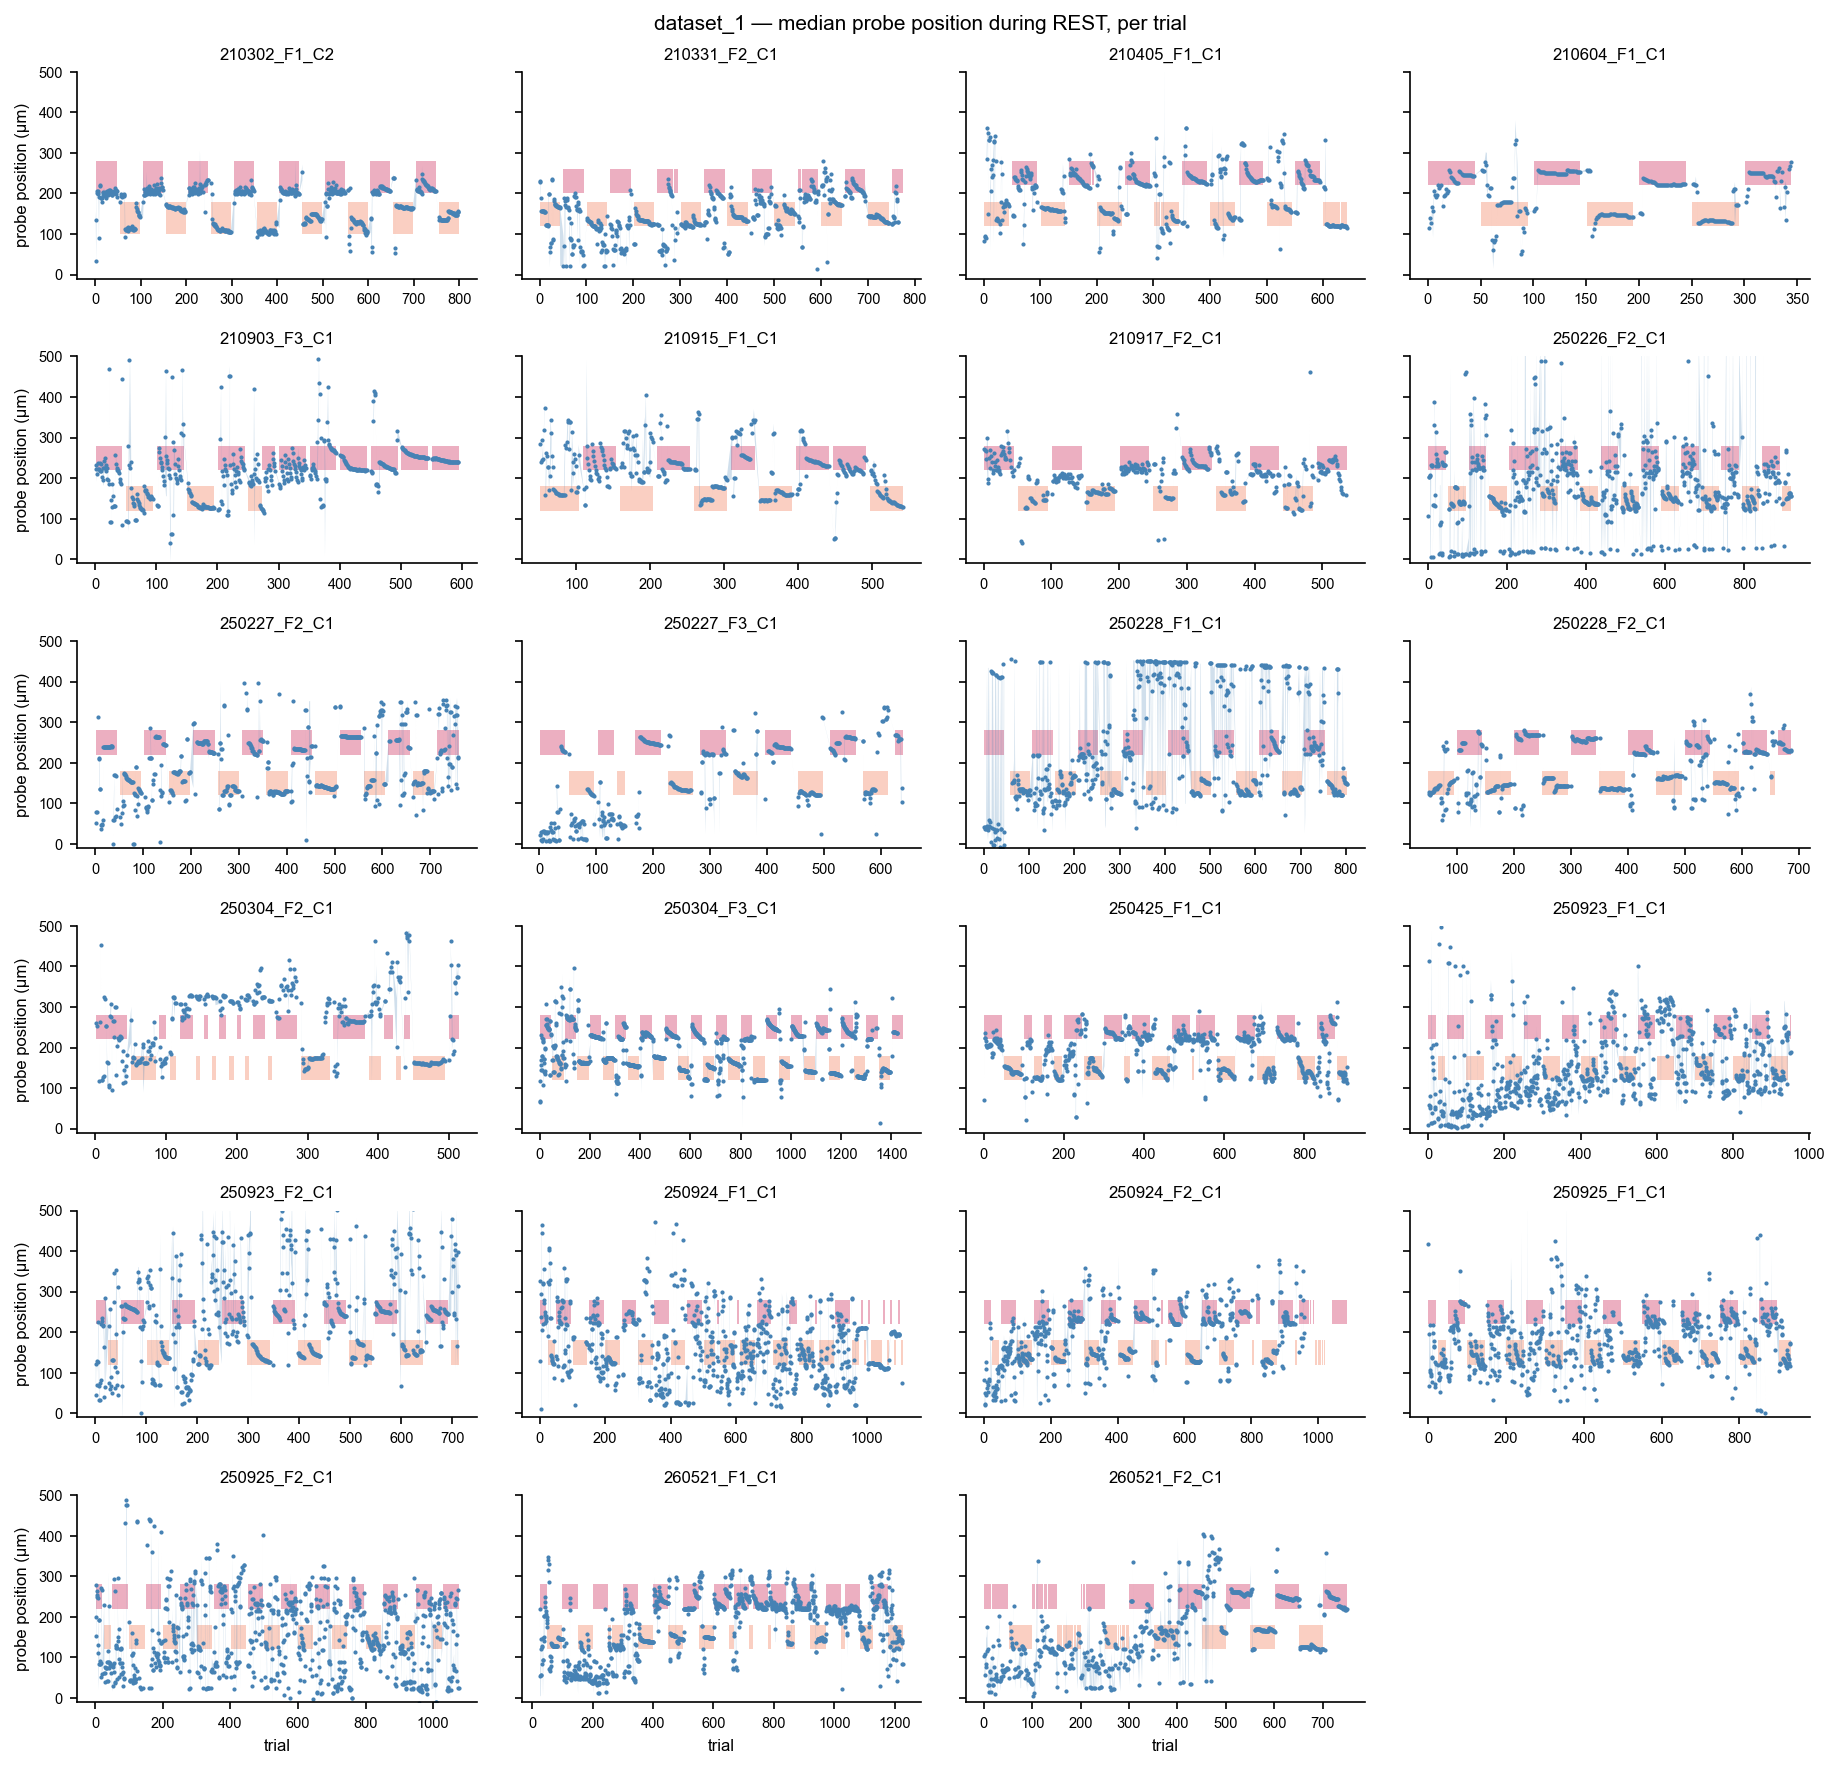

In [108]:
group_name = 'dataset_1'
display(plot_rest_position_across_trials(cohort_frame(group_name, 'trials'), group_name,save=True))

saved Figure5_mutant_plots/rest_position_summary_w_vs_dataset_1.svg


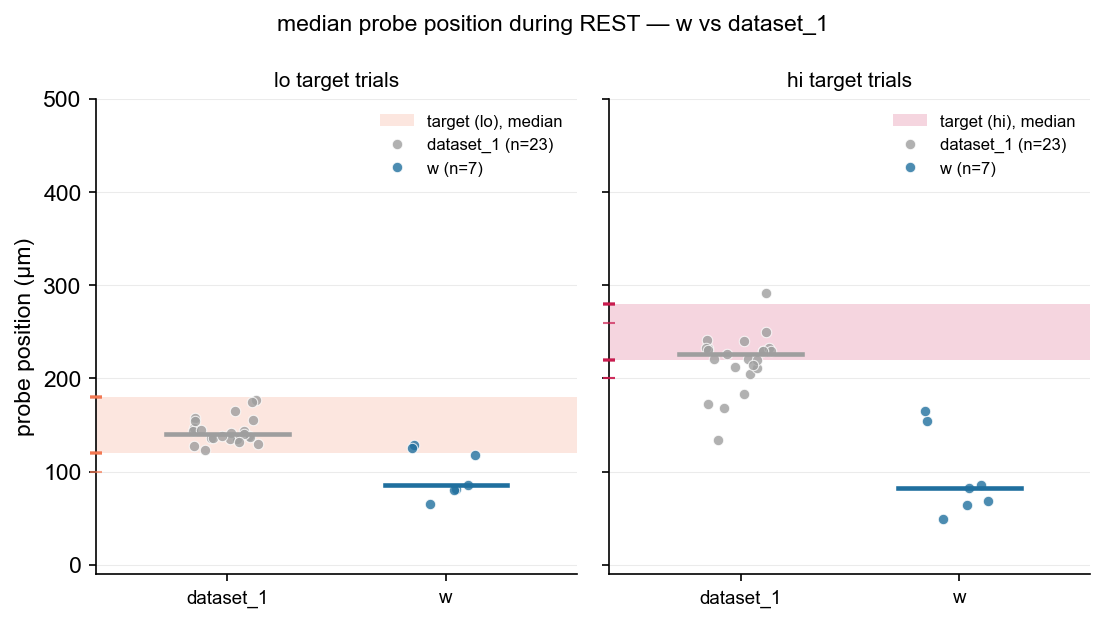

dataset_1: 0.8% of bouts and 3.1% of rest time sits in bouts a chunk edge cut short
w: 0.8% of bouts and 1.9% of rest time sits in bouts a chunk edge cut short
saved Figure5_mutant_plots/rest_durations_w_vs_dataset_1.svg


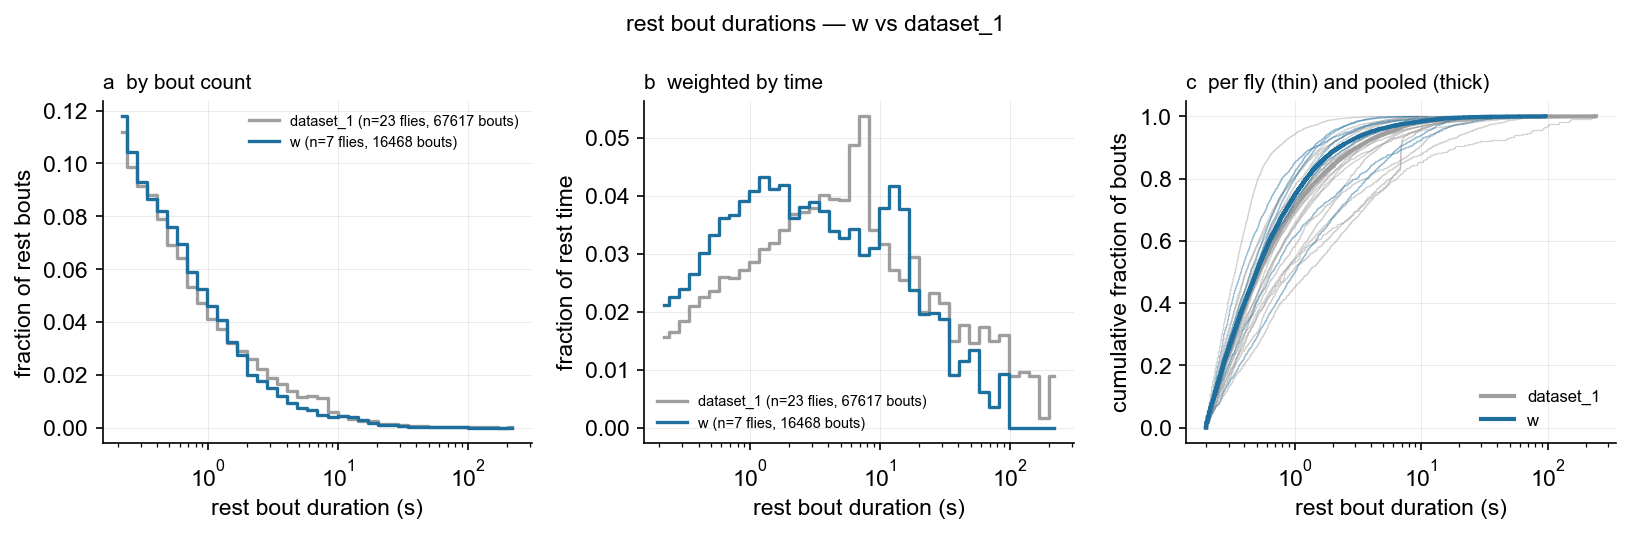

saved Figure5_mutant_plots/rest_time_w_vs_dataset_1.svg


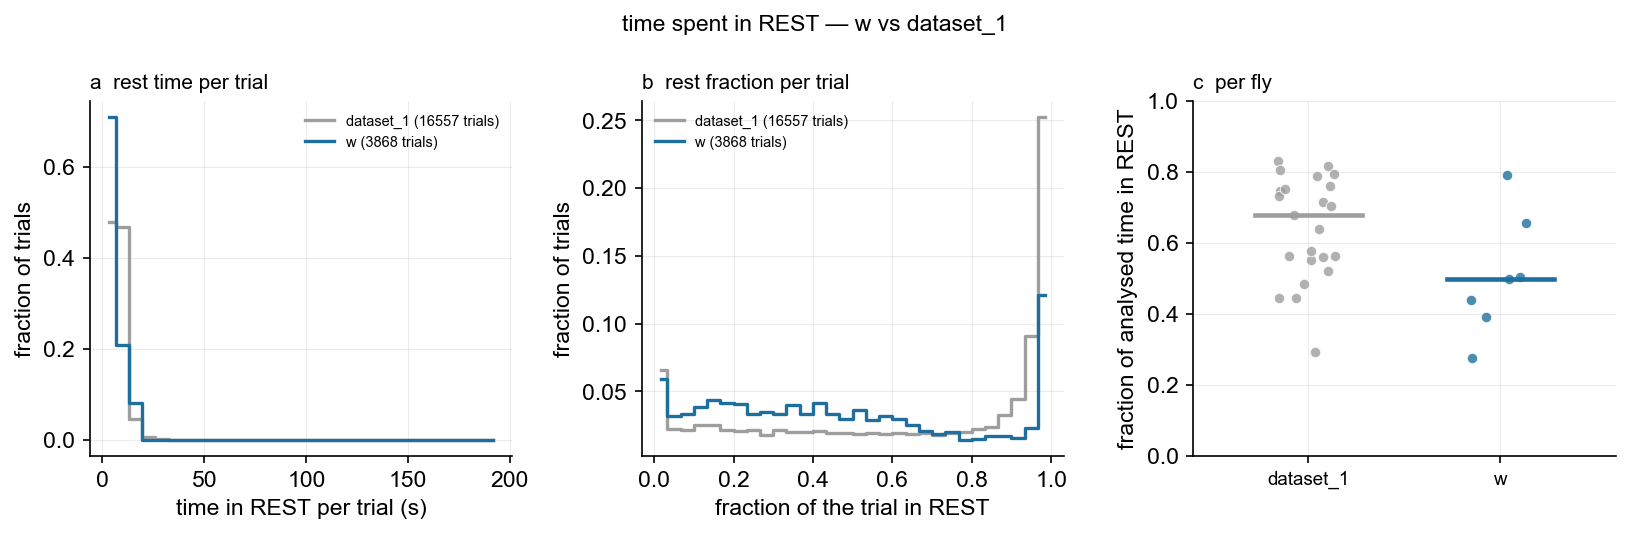

  note: 2117.4 s of all time (1.0%) falls outside the position bins and is not plotted
saved Figure5_mutant_plots/rest_position_pdf_w_vs_dataset_1.svg


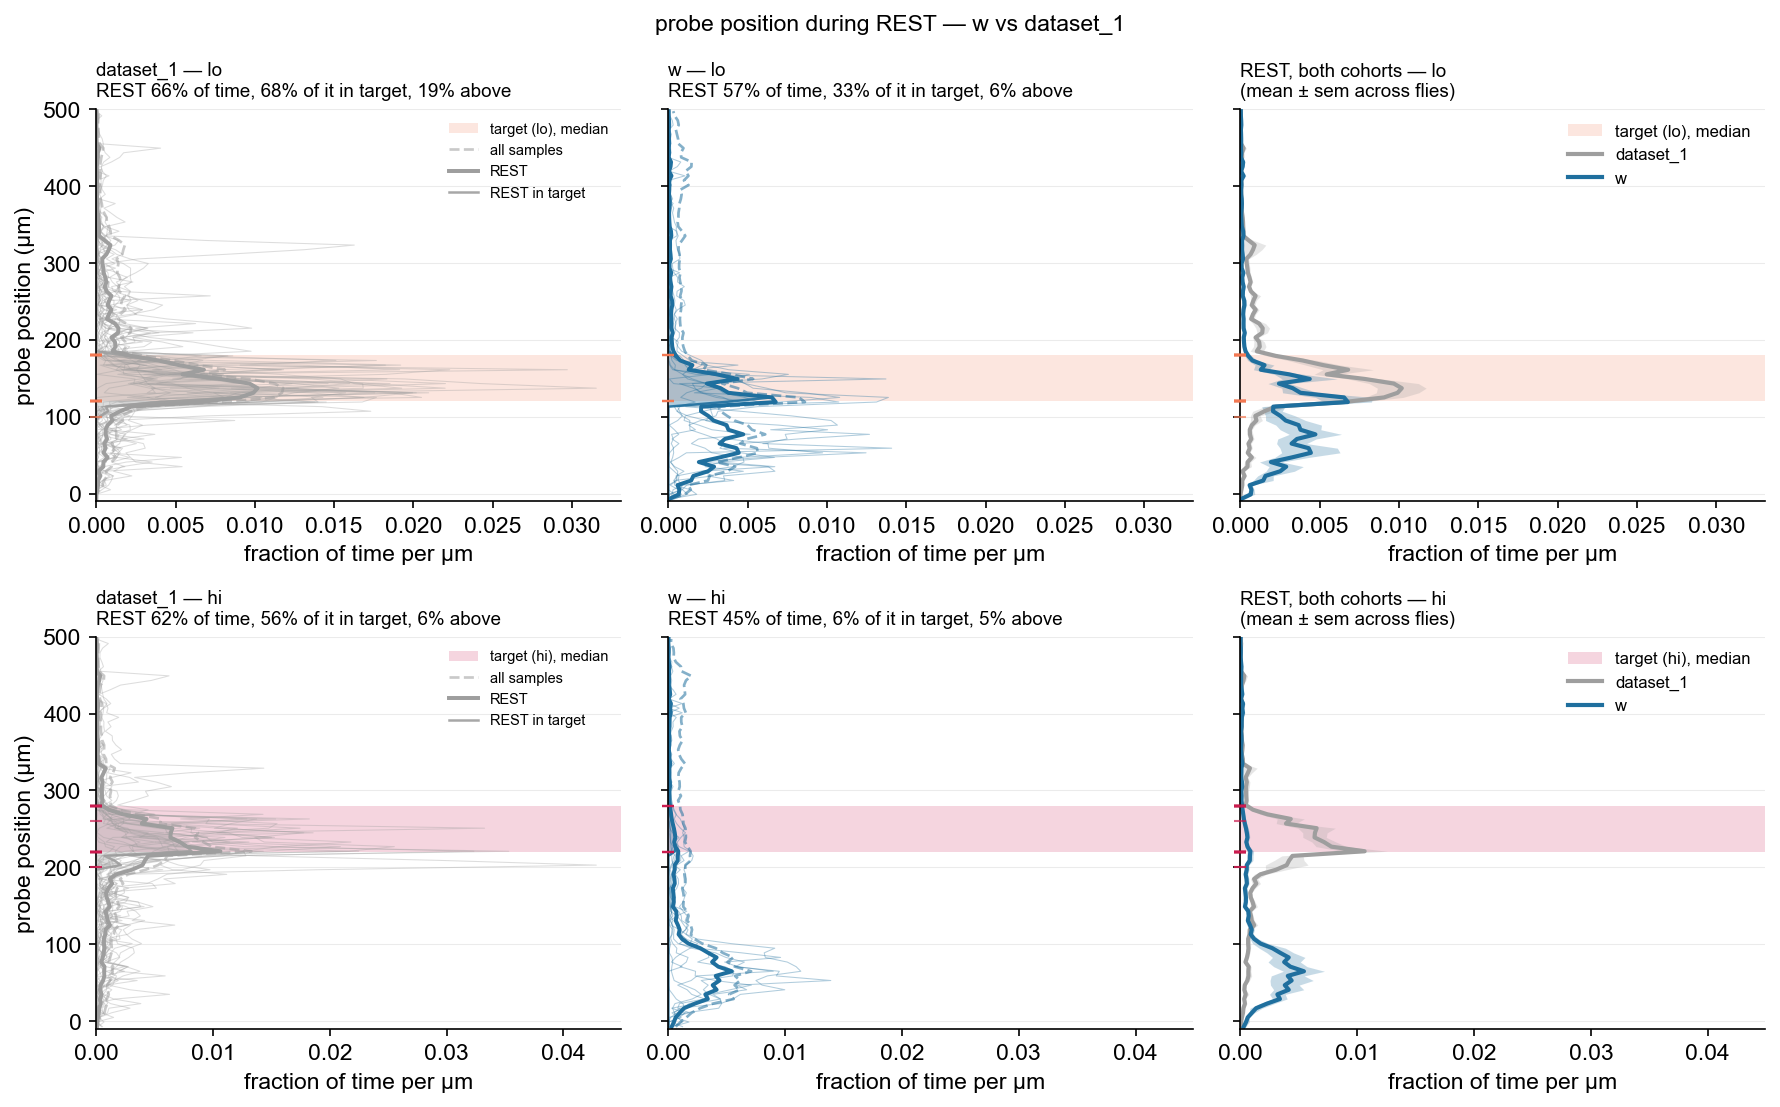

saved Figure5_mutant_plots/rest_rest_position_across_trials_w_vs_dataset_1.svg


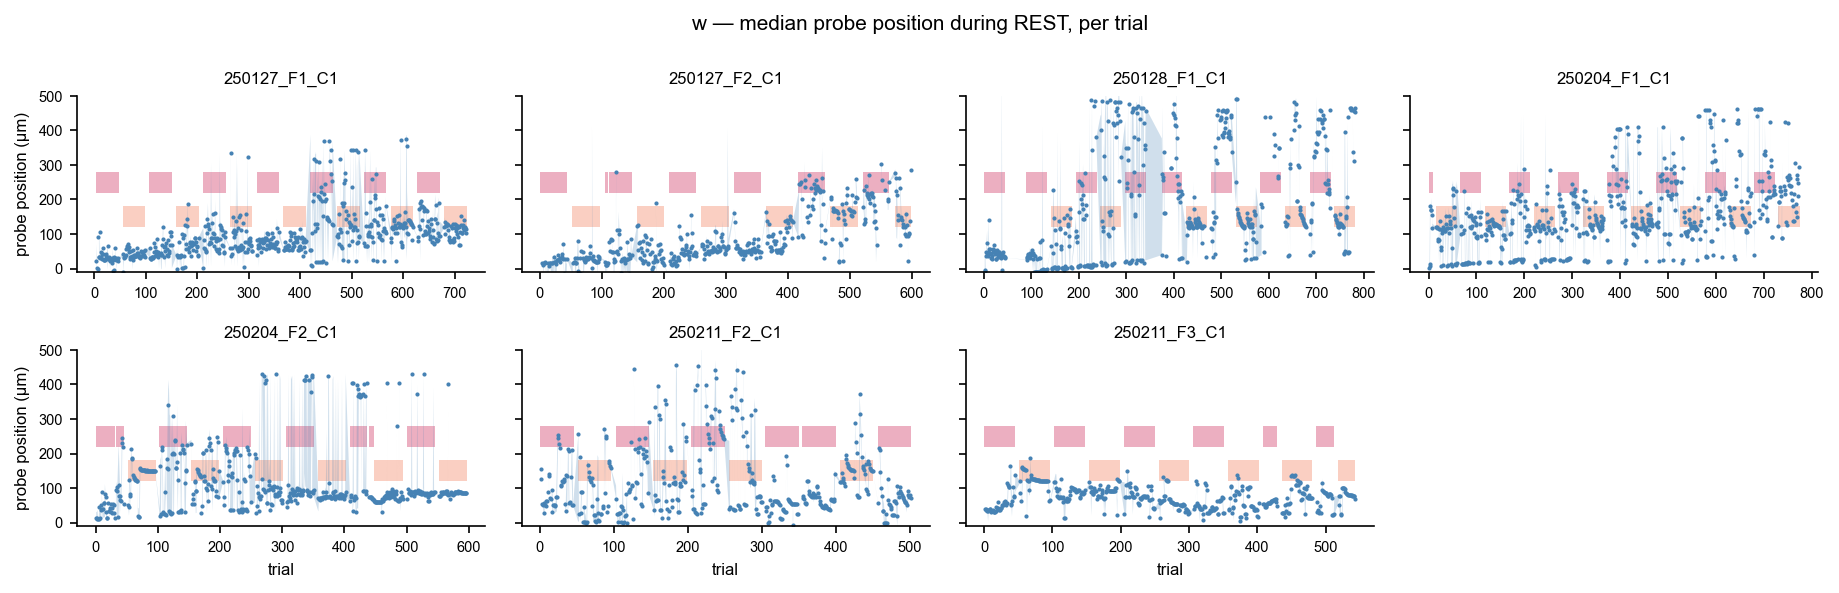

'                 cohort                               genotype  v_rest  n_trials  rest_fraction  frac_state_in_target  frac_state_above_target  frac_time_state_in_target  median_bout_s  time_weighted_median_bout_s  median_trial_position_p50  median_bout_position_rel_hi\ndfc                                                                                                                                                                                                                                                                          \n210302_F1_C2  dataset_1                   Hot-Cell-Gal4 (test)      30       705         0.7876                 0.838                  0.05249                       0.66         0.6401                        2.732                      189.3                       -66.29\n210331_F2_C1  dataset_1  +;Hot-Cell-LexA_Chr;81A06-GAL4_pJFRC7      32       678         0.6798                0.4322                   0.0601                     0.2938           0.53  

saved Figure5_mutant_plots/rest_position_summary_w_iav_vs_dataset_1.svg


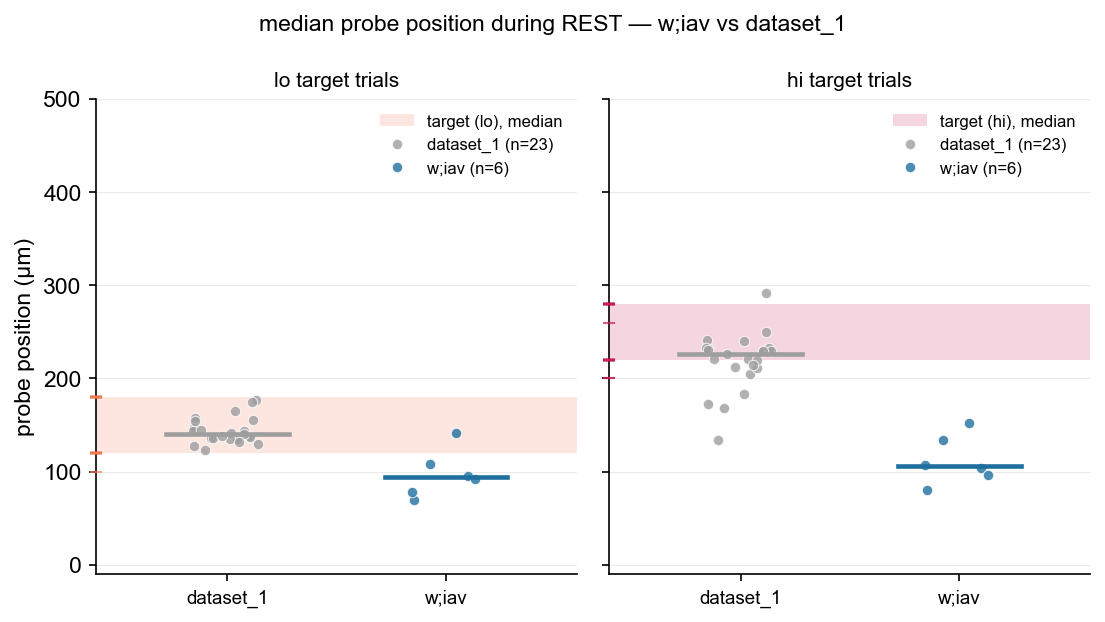

dataset_1: 0.8% of bouts and 3.1% of rest time sits in bouts a chunk edge cut short
w;iav: 0.7% of bouts and 1.5% of rest time sits in bouts a chunk edge cut short
saved Figure5_mutant_plots/rest_durations_w_iav_vs_dataset_1.svg


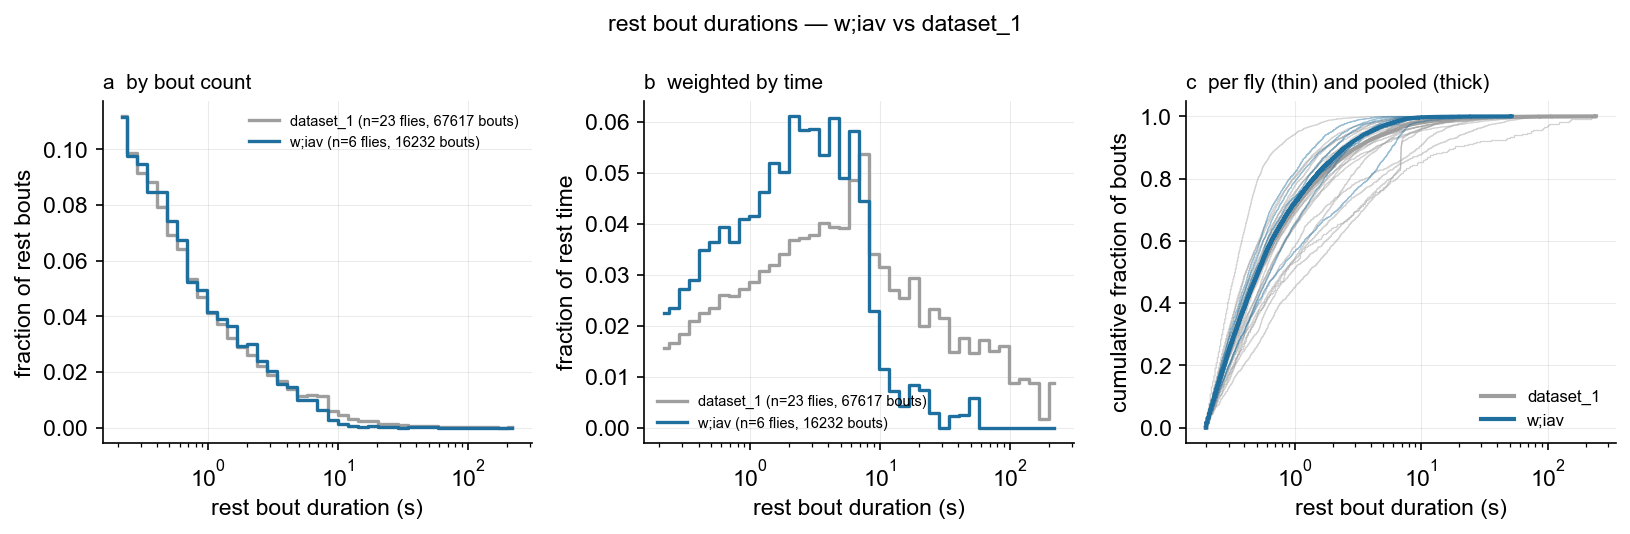

saved Figure5_mutant_plots/rest_time_w_iav_vs_dataset_1.svg


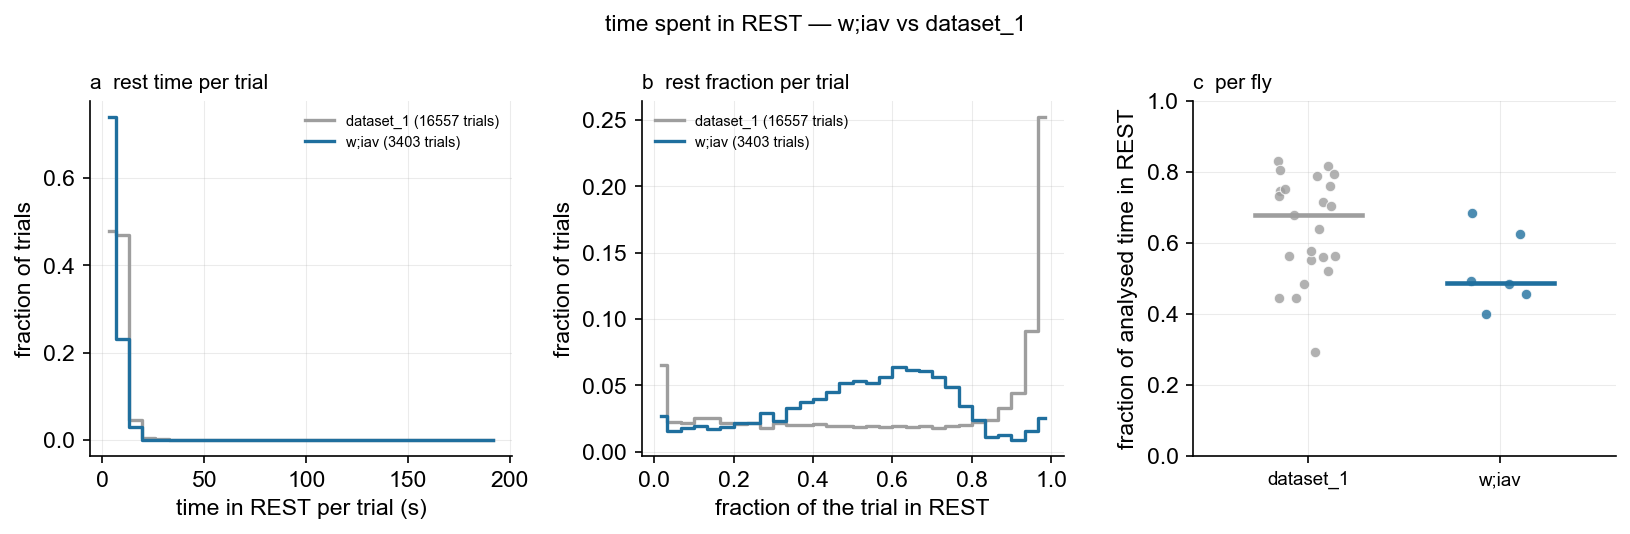

saved Figure5_mutant_plots/rest_position_pdf_w_iav_vs_dataset_1.svg


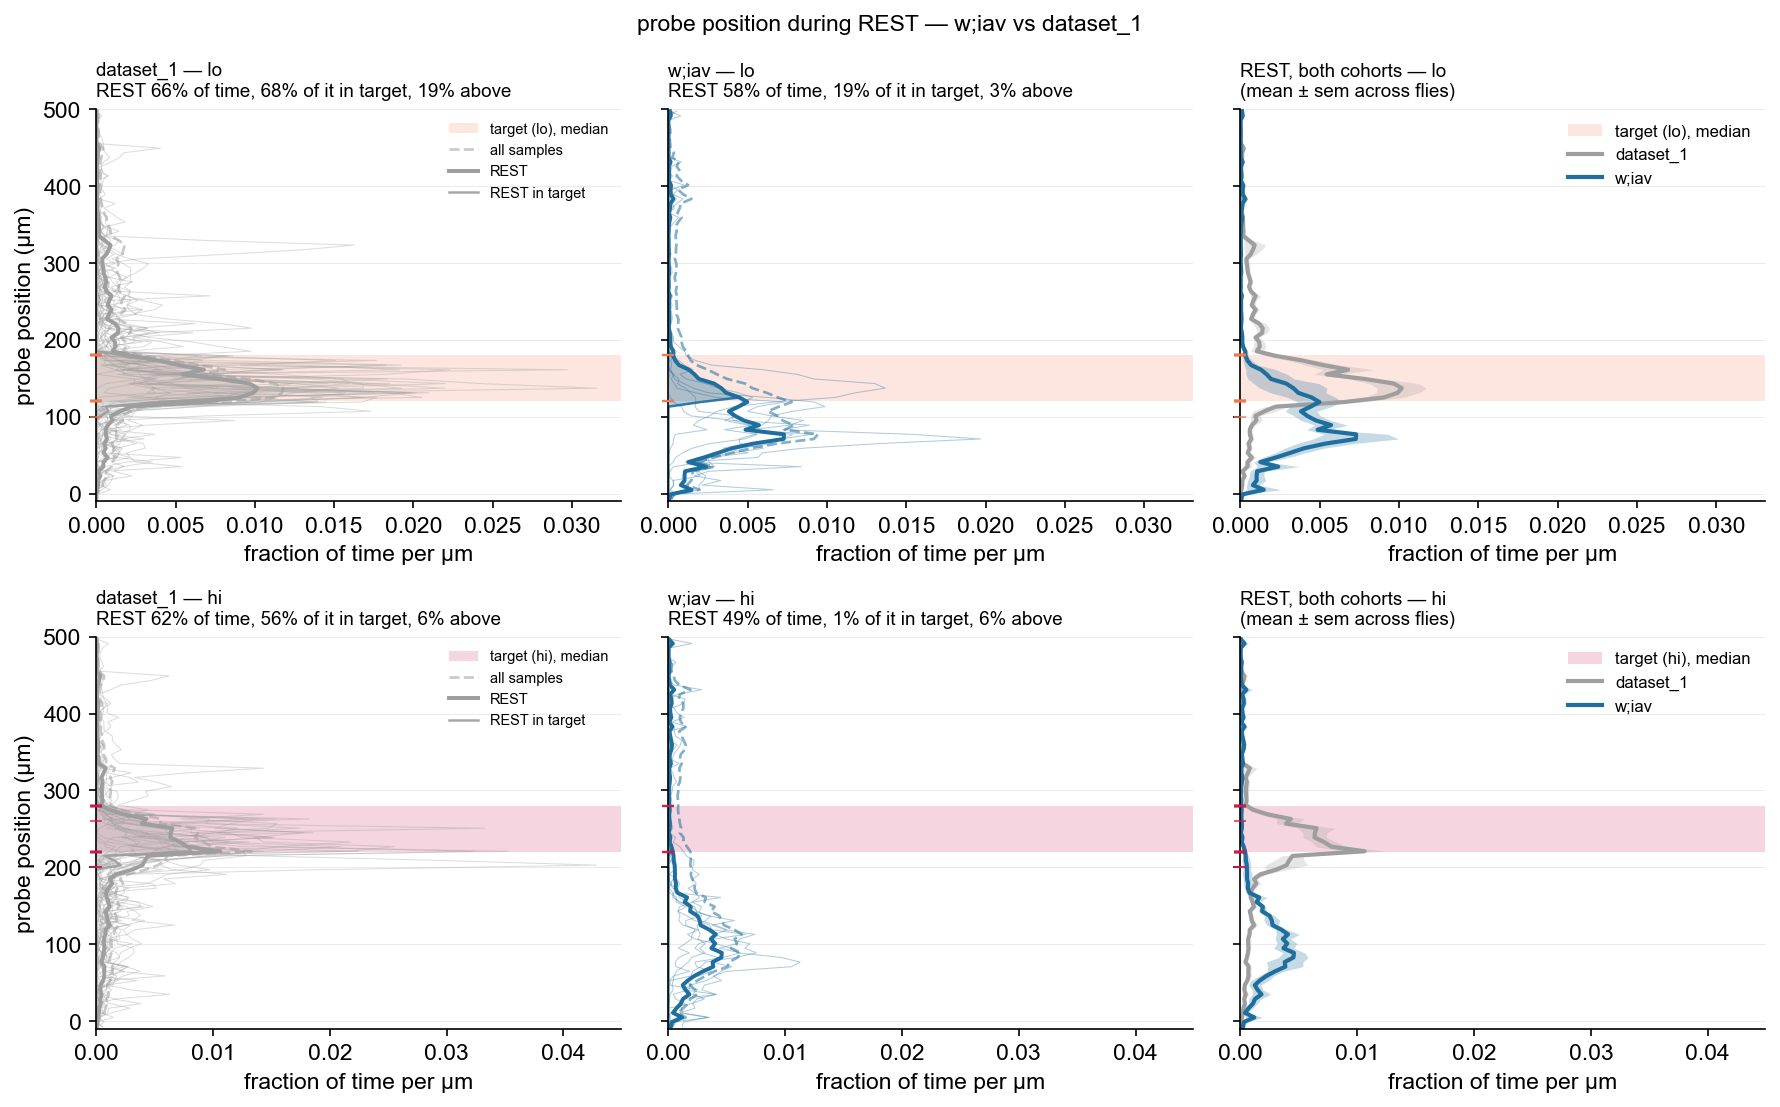

saved Figure5_mutant_plots/rest_rest_position_across_trials_w_iav_vs_dataset_1.svg


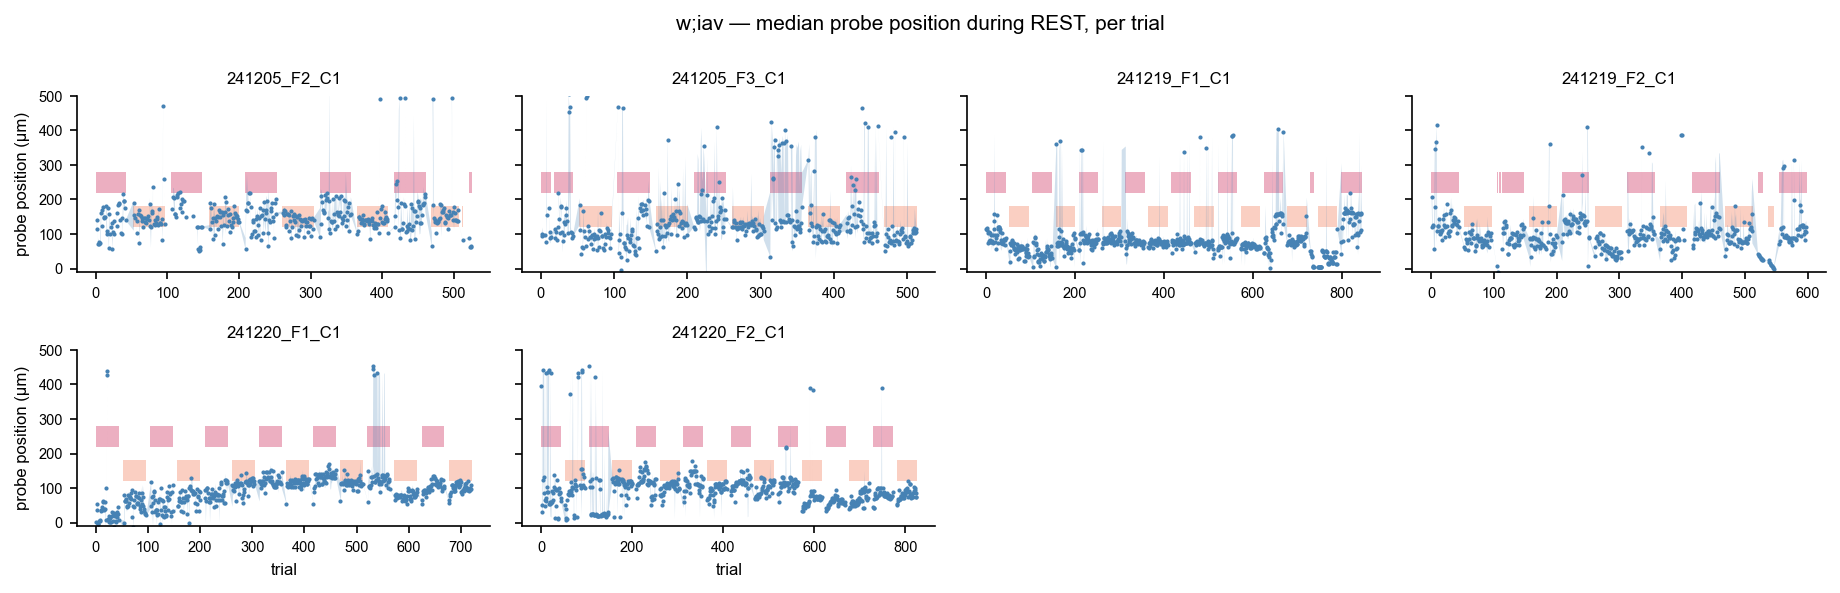

'                 cohort                               genotype  v_rest  n_trials  rest_fraction  frac_state_in_target  frac_state_above_target  frac_time_state_in_target  median_bout_s  time_weighted_median_bout_s  median_trial_position_p50  median_bout_position_rel_hi\ndfc                                                                                                                                                                                                                                                                          \n210302_F1_C2  dataset_1                   Hot-Cell-Gal4 (test)      30       705         0.7876                 0.838                  0.05249                       0.66         0.6401                        2.732                      189.3                       -66.29\n210331_F2_C1  dataset_1  +;Hot-Cell-LexA_Chr;81A06-GAL4_pJFRC7      32       678         0.6798                0.4322                   0.0601                     0.2938           0.53  

saved Figure5_mutant_plots/rest_position_summary_PAM_vs_dataset_1.svg


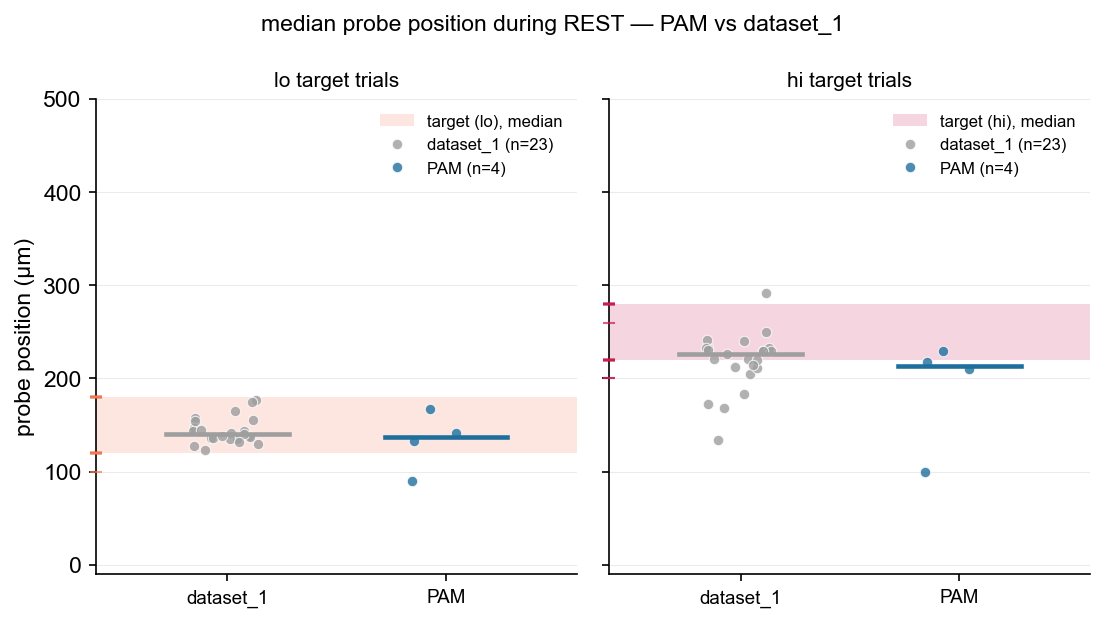

dataset_1: 0.8% of bouts and 3.1% of rest time sits in bouts a chunk edge cut short
PAM: 0.1% of bouts and 0.1% of rest time sits in bouts a chunk edge cut short
saved Figure5_mutant_plots/rest_durations_PAM_vs_dataset_1.svg


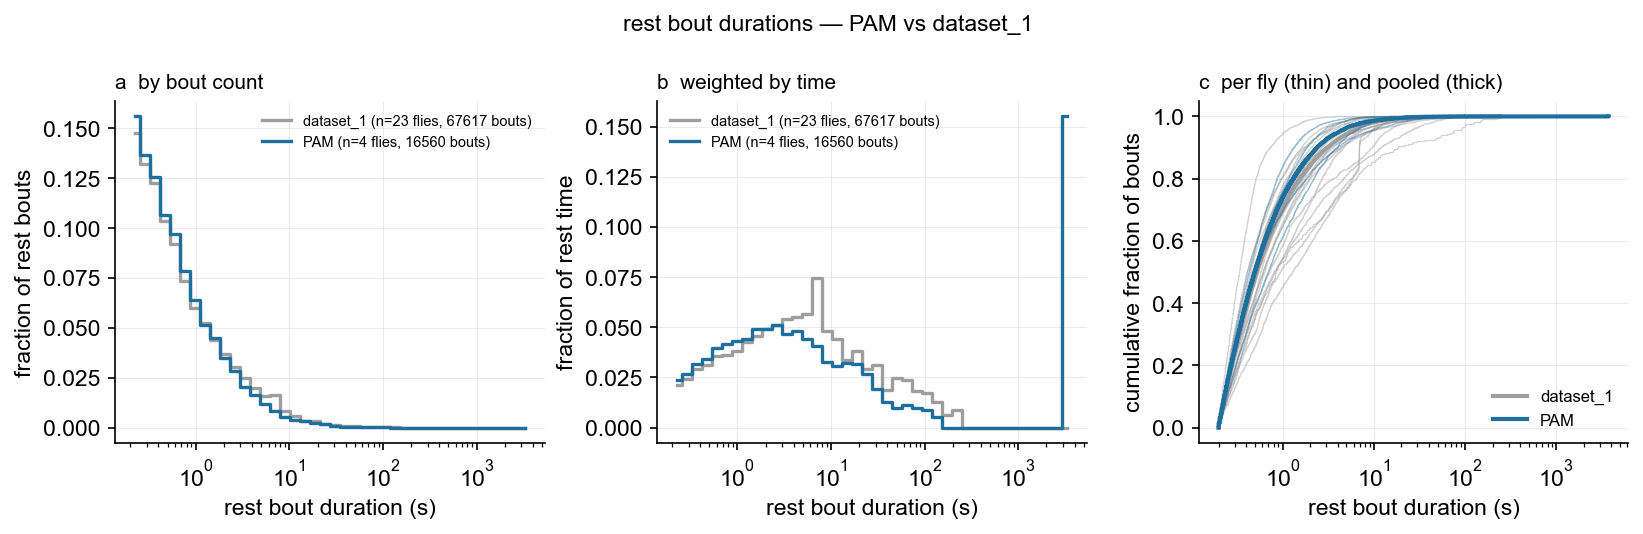

saved Figure5_mutant_plots/rest_time_PAM_vs_dataset_1.svg


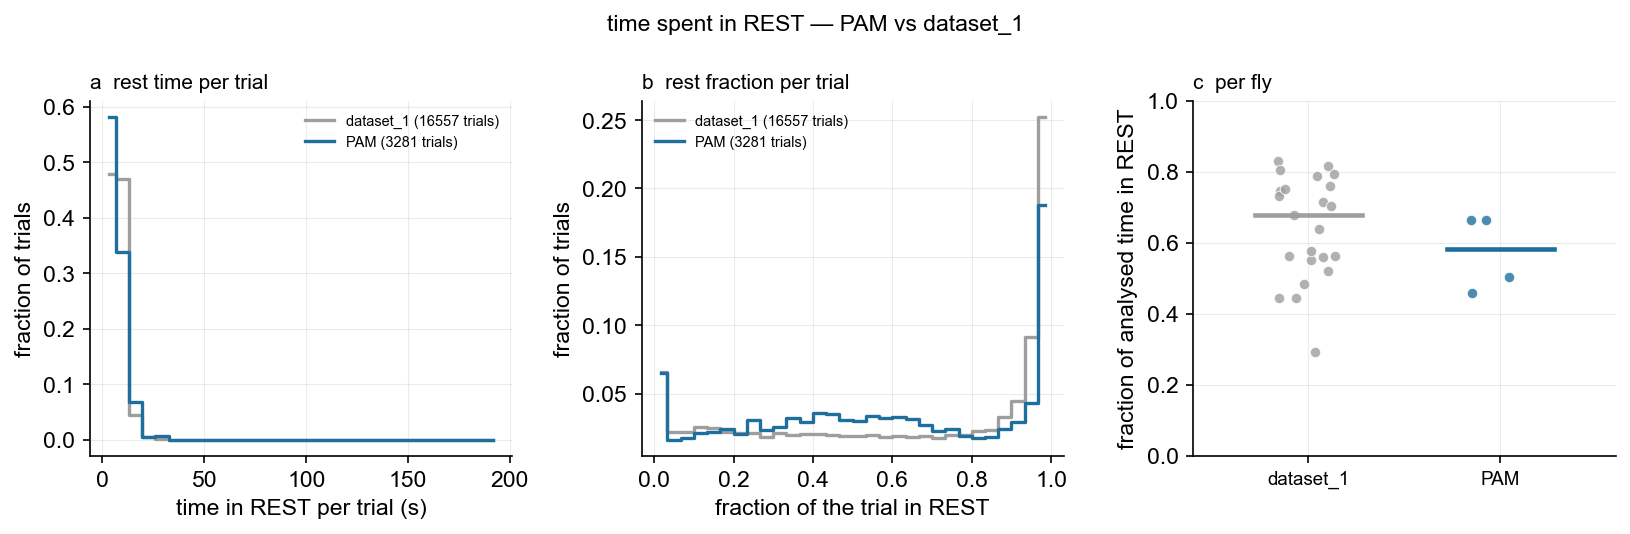

  note: 2532.6 s of all time (1.3%) falls outside the position bins and is not plotted
saved Figure5_mutant_plots/rest_position_pdf_PAM_vs_dataset_1.svg


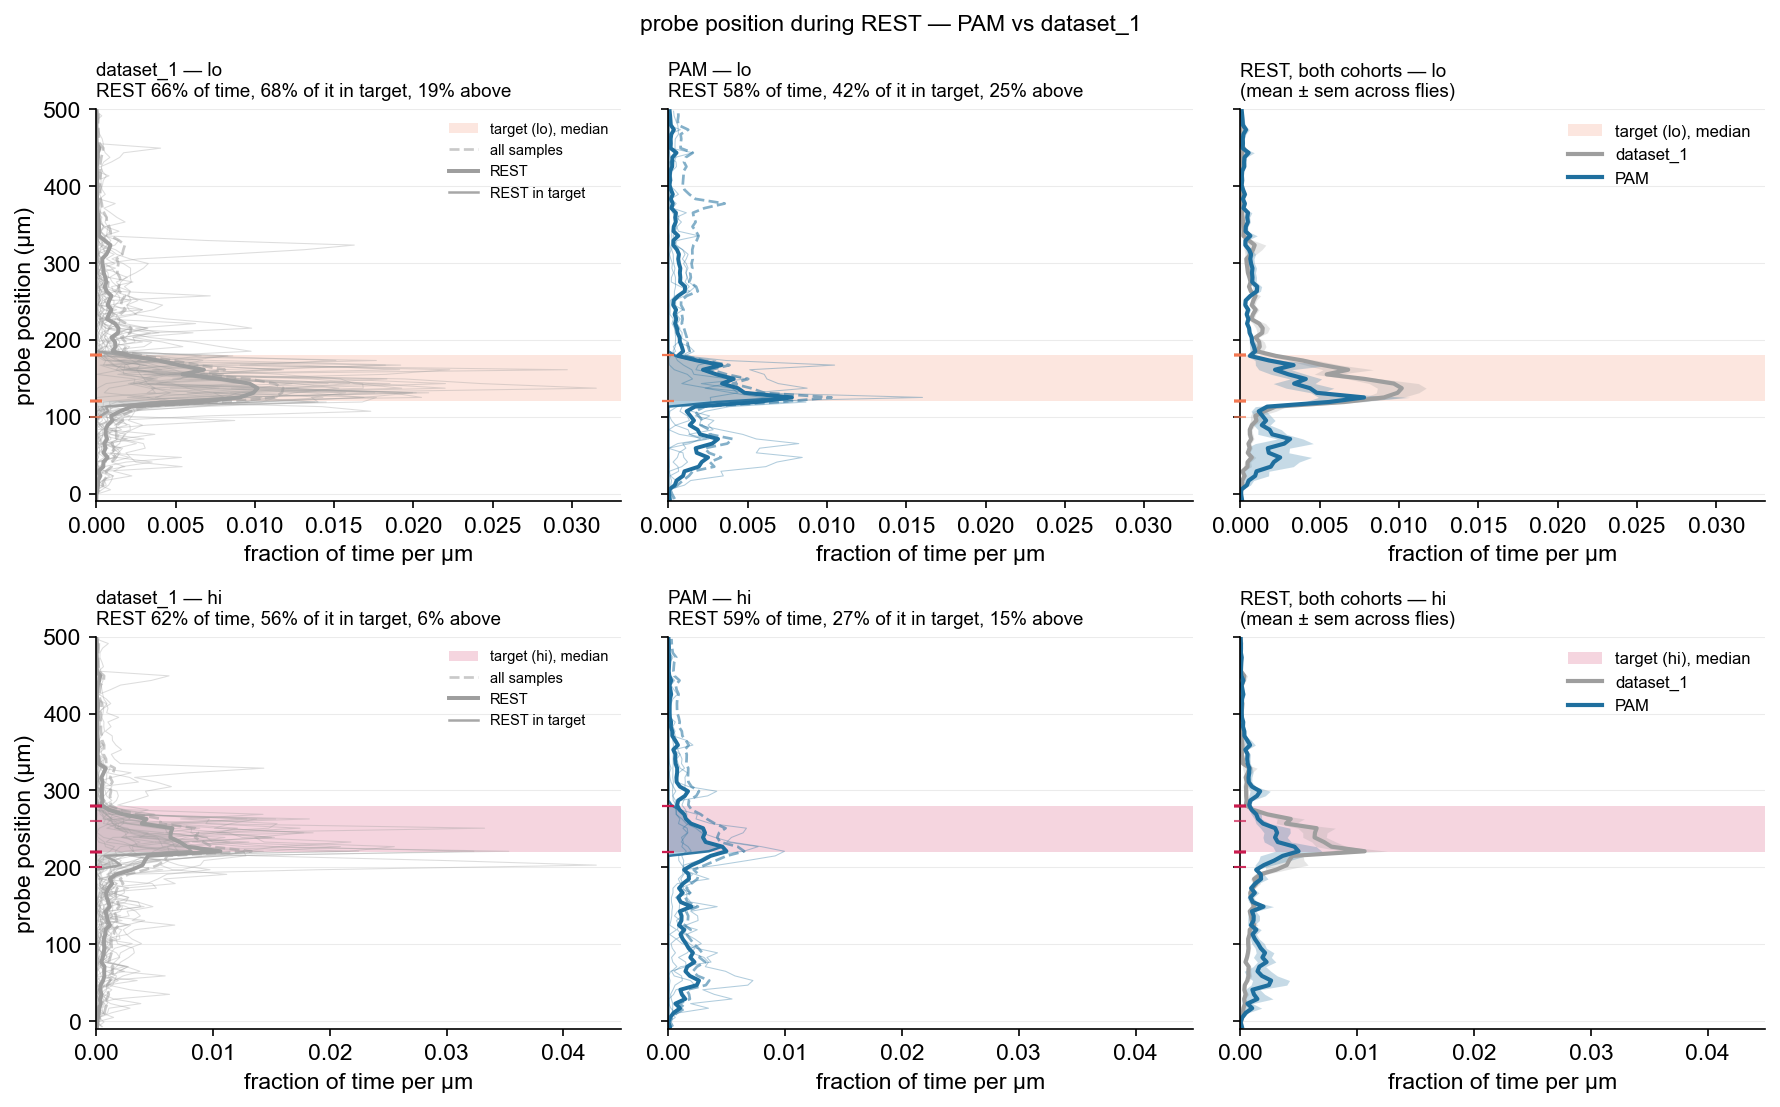

saved Figure5_mutant_plots/rest_rest_position_across_trials_PAM_vs_dataset_1.svg


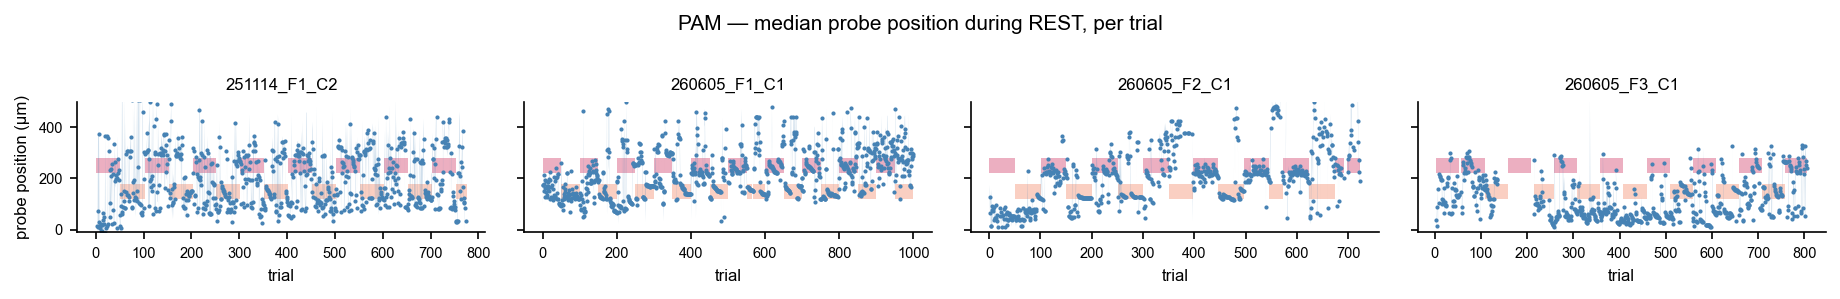

'                 cohort                               genotype  v_rest  n_trials  rest_fraction  frac_state_in_target  frac_state_above_target  frac_time_state_in_target  median_bout_s  time_weighted_median_bout_s  median_trial_position_p50  median_bout_position_rel_hi\ndfc                                                                                                                                                                                                                                                                          \n210302_F1_C2  dataset_1                   Hot-Cell-Gal4 (test)      30       705         0.7876                 0.838                  0.05249                       0.66         0.6401                        2.732                      189.3                       -66.29\n210331_F2_C1  dataset_1  +;Hot-Cell-LexA_Chr;81A06-GAL4_pJFRC7      32       678         0.6798                0.4322                   0.0601                     0.2938           0.53  

saved Figure5_mutant_plots/rest_position_summary_PPL_vs_dataset_1.svg


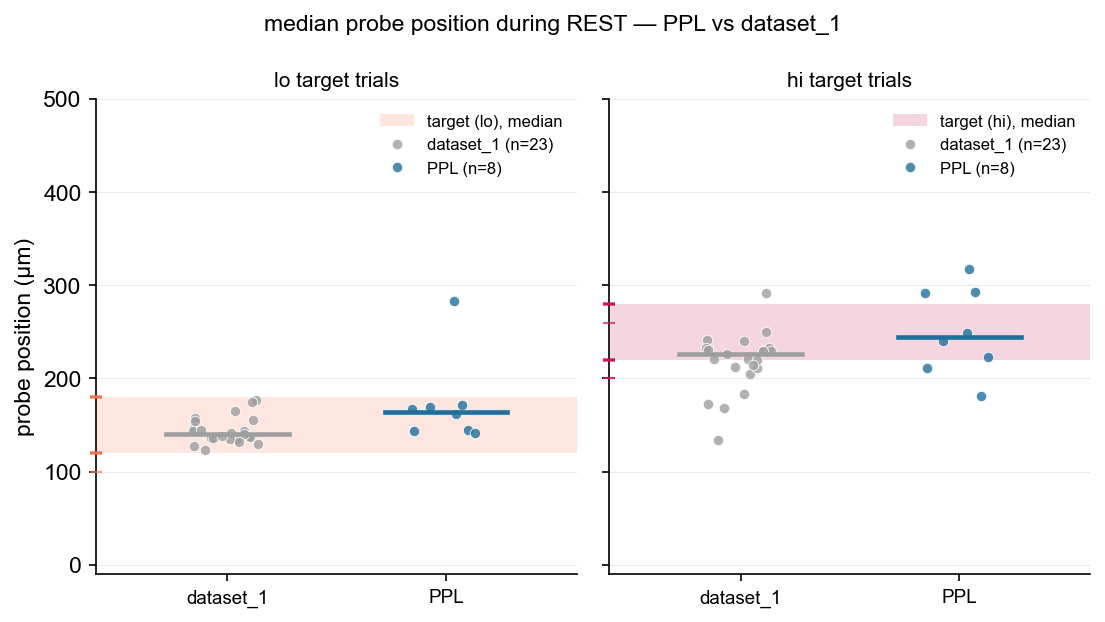

dataset_1: 0.8% of bouts and 3.1% of rest time sits in bouts a chunk edge cut short
PPL: 1.0% of bouts and 2.4% of rest time sits in bouts a chunk edge cut short
saved Figure5_mutant_plots/rest_durations_PPL_vs_dataset_1.svg


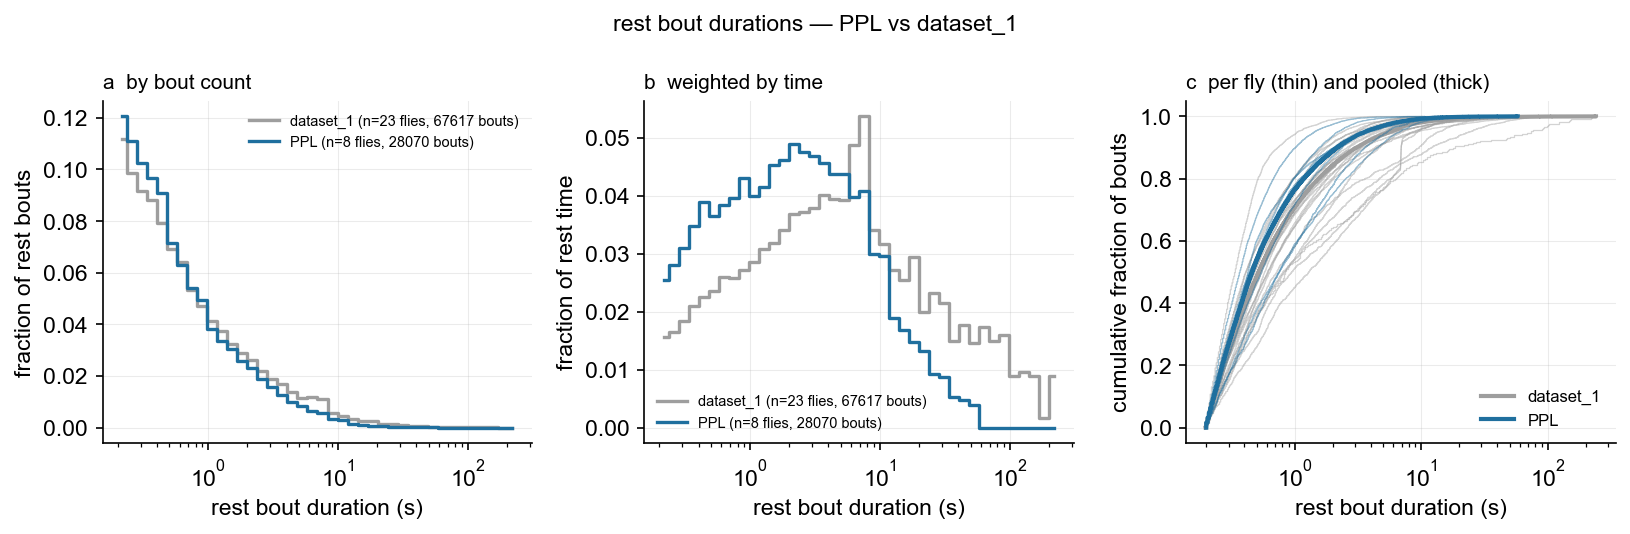

saved Figure5_mutant_plots/rest_time_PPL_vs_dataset_1.svg


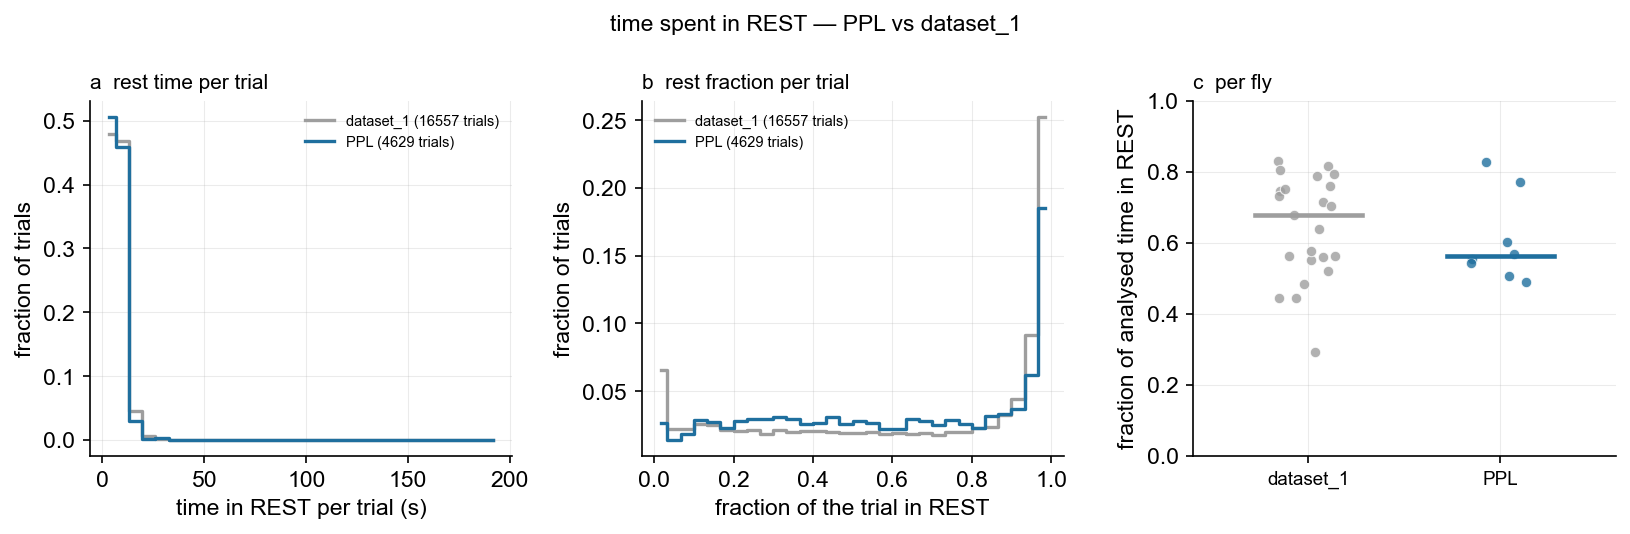

  note: 2512.9 s of all time (1.2%) falls outside the position bins and is not plotted
saved Figure5_mutant_plots/rest_position_pdf_PPL_vs_dataset_1.svg


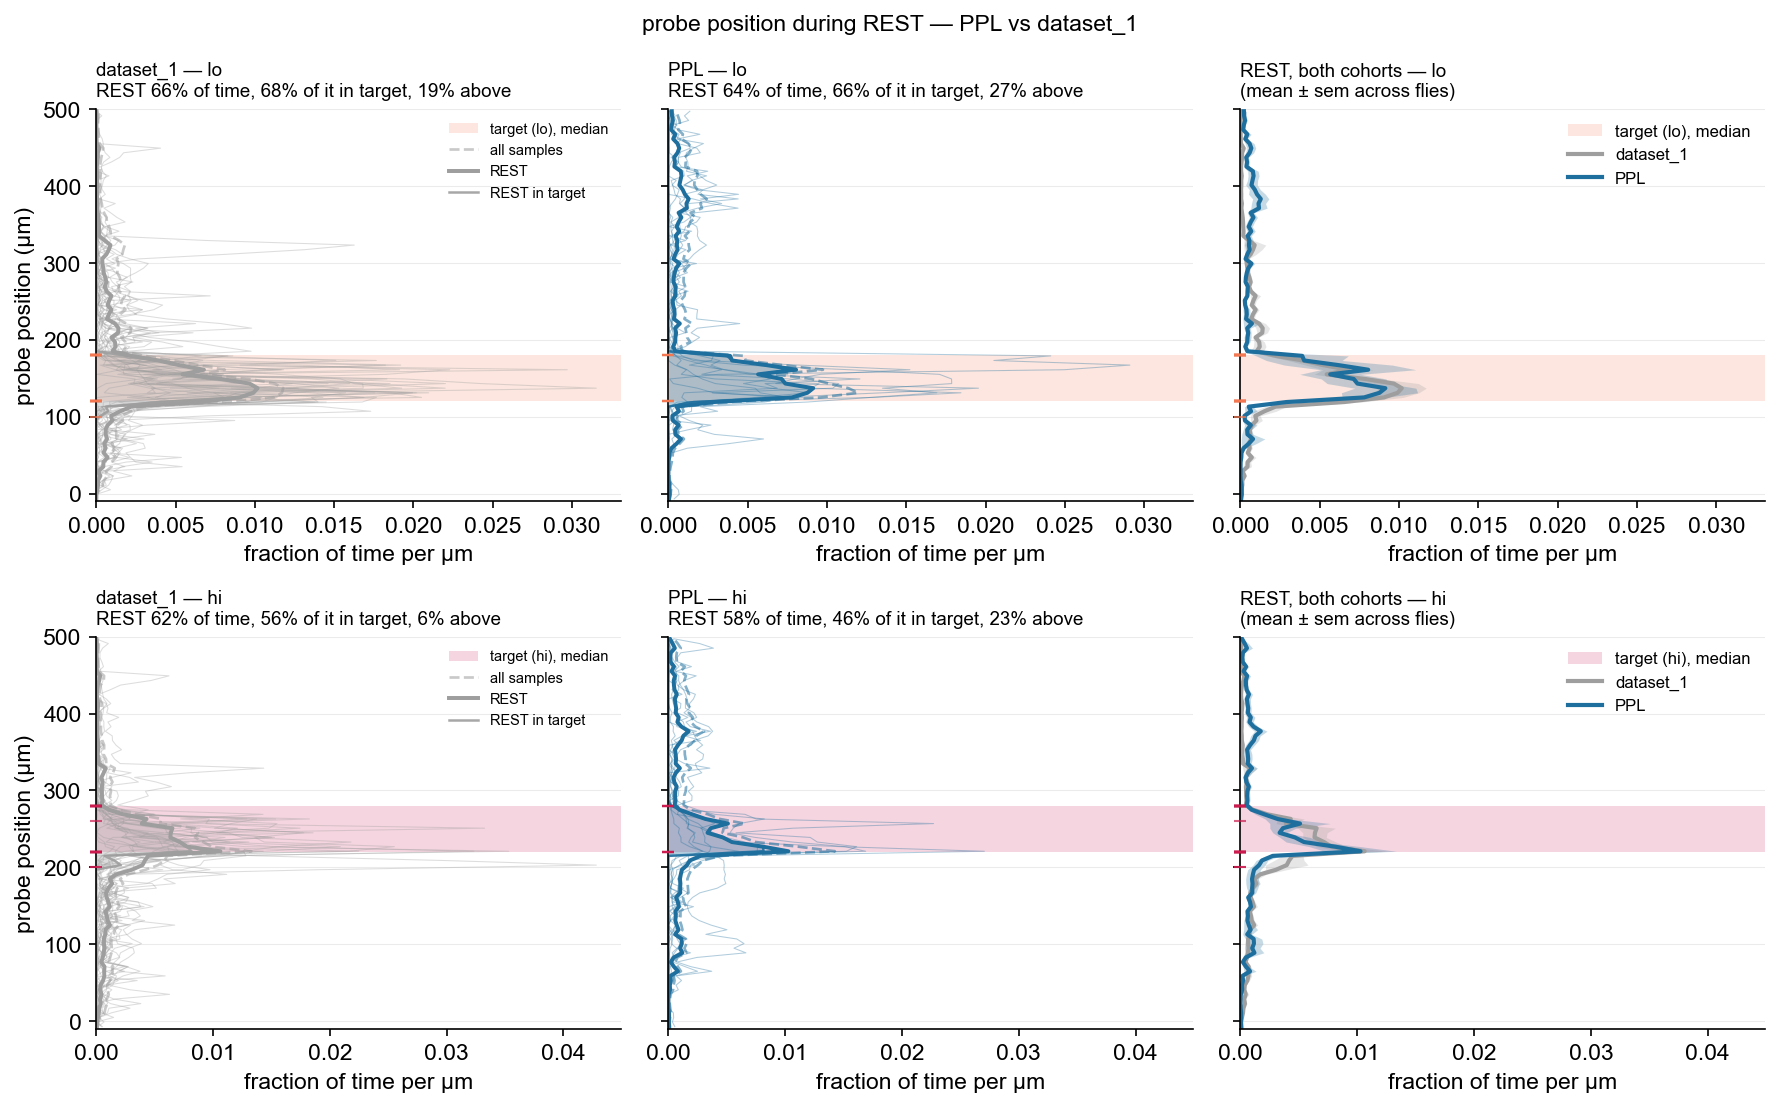

saved Figure5_mutant_plots/rest_rest_position_across_trials_PPL_vs_dataset_1.svg


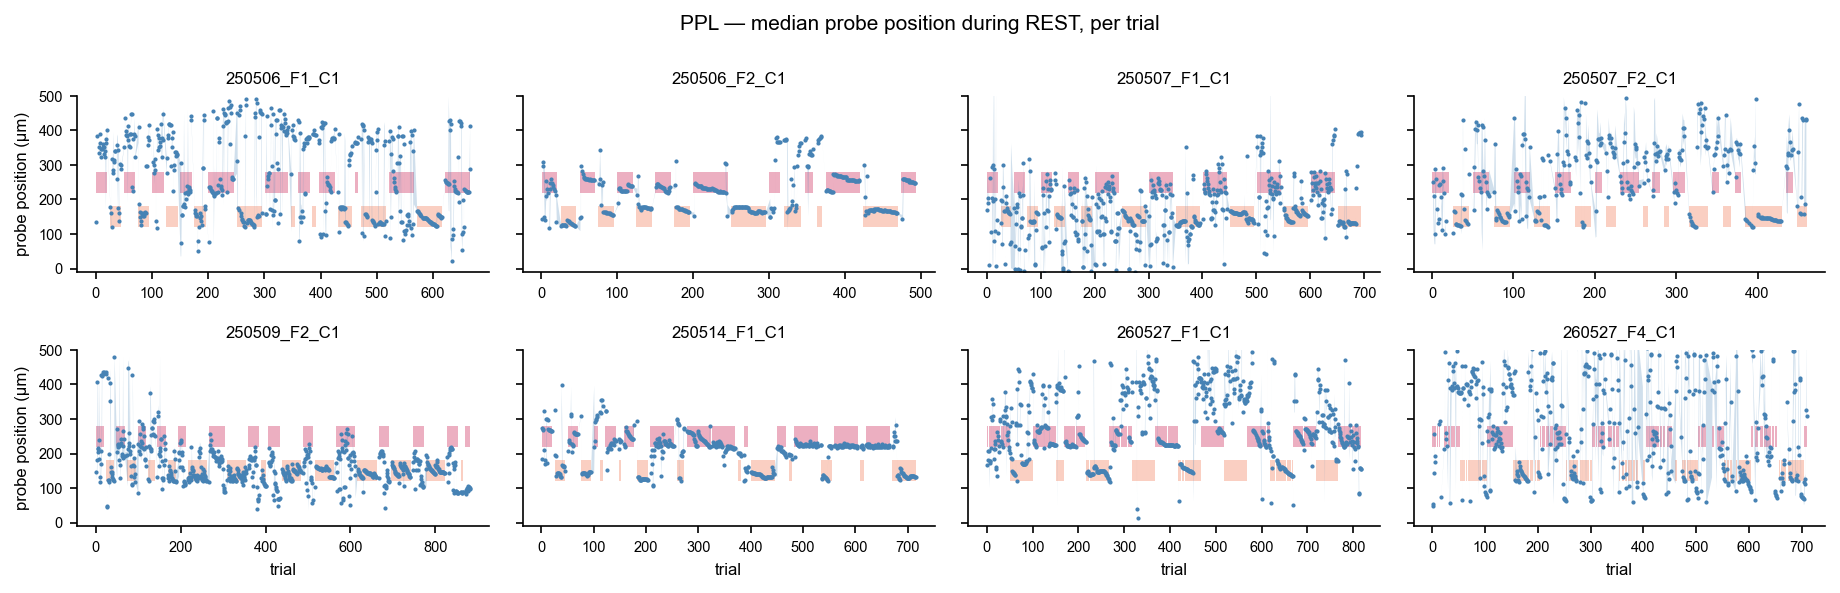

'                 cohort                               genotype  v_rest  n_trials  rest_fraction  frac_state_in_target  frac_state_above_target  frac_time_state_in_target  median_bout_s  time_weighted_median_bout_s  median_trial_position_p50  median_bout_position_rel_hi\ndfc                                                                                                                                                                                                                                                                          \n210302_F1_C2  dataset_1                   Hot-Cell-Gal4 (test)      30       705         0.7876                 0.838                  0.05249                       0.66         0.6401                        2.732                      189.3                       -66.29\n210331_F2_C1  dataset_1  +;Hot-Cell-LexA_Chr;81A06-GAL4_pJFRC7      32       678         0.6798                0.4322                   0.0601                     0.2938           0.53  

In [105]:
# --- one group at a time ----------------------------------------------------
group_names = ['w']

# --- all groups at a time ----------------------------------------------------
group_names = ['w','w;iav','PAM','PPL']

for group_name in group_names:
        save_flag = True
        display(plot_rest_position_summary(group_name, save=save_flag))
        display(plot_rest_durations(group_name, save=save_flag))
        display(plot_rest_time(group_name, save=save_flag))
        display(plot_rest_position_pdfs(group_name, save=save_flag))

        # the per-fly across-trials view, one cohort at a time (tall figures)
        display(plot_rest_position_across_trials(cohort_frame(group_name, 'trials'), group_name,save=True))
        # display(plot_rest_position_across_trials(cohort_frame(REFERENCE_NAME, 'trials'), REFERENCE_NAME))

        # per-fly numbers behind the panels
        summary_columns = ['cohort', 'genotype', 'v_rest', 'n_trials', 'rest_fraction',
                        'frac_state_in_target', 'frac_state_above_target',
                        'frac_time_state_in_target', 'median_bout_s',
                        'time_weighted_median_bout_s', 'median_trial_position_p50',
                        'median_bout_position_rel_hi']
        summaries = rest_summaries()
        display(summaries[[c for c in summary_columns if c in summaries.columns]]
                .set_index(summaries['dfc'])
                .to_string(float_format=lambda v: f'{v:.4g}'))

In [91]:
# ---------------------------------------------------------------------------
# Check the noise-scaled v_rest against the state-fraction lines
# ---------------------------------------------------------------------------
# Same figure as `fraction_lines()` in op_cond_Figure5_iav_mutants.ipynb, but fed
# from the collection frames instead of the cached Sinq scalars.
#
# Read the comparison carefully. The existing
# Figure5_mutant_plots/state_fraction_lines_{learners,iav}.svg came from the Sinq
# columns rest/drift/move_time_fraction, which table_scalars computes with
# DEFAULT thresholds, per trial, post-stim samples only. These come from the
# across-trials classification over the whole trace. So a difference between the
# old and the new figure mixes both changes together. To see the effect of v_rest
# alone, compare two collections from THIS machinery -- the default-threshold
# cache and the noise-scaled one, which CACHE_SUFFIX keeps side by side:
#
#     trials_default = collect_rest_group(sinq_g, GROUPS['PPL'], 'PPL',
#                                         cache_suffix='')[1]

def fraction_lines(summary, columns=('rest_time_fraction', 'drift_time_fraction',
                                     'move_time_fraction'),
                   jitter=0.05, title=None, savepath=None,
                   width=950, height=600):
    """Per-fly state fractions as connected dots, thick black median.

    Lifted from the iav notebook so the two figures stay comparable. Takes any
    frame indexed by dfc carrying the three fraction columns -- including the
    output of `ba.occupancy_summary_by_fly`, whose columns are named to match.
    """
    columns = list(columns)
    offsets = pd.Series(np.linspace(-jitter, jitter, len(summary)),
                        index=summary.index)
    long = (summary[columns].rename_axis('dfc').reset_index()
            .melt(id_vars='dfc', var_name='state', value_name='frac'))
    long['x'] = (long['state'].map({s: i for i, s in enumerate(columns)})
                 + long['dfc'].map(offsets))
    long['label'] = np.where(long['state'] == columns[-1], long['dfc'], '')

    fig = px.line(long, x='x', y='frac', color='dfc', markers=True, text='label',
                  hover_name='dfc', template='simple_white', title=title,
                  labels={'frac': 'time fraction', 'x': 'state'})
    fig.update_traces(textposition='middle right', textfont_size=9)

    median = summary[columns].median()
    fig.add_scatter(x=list(range(len(columns))), y=median.values,
                    mode='lines+markers', name='median',
                    line=dict(color='black', width=4),
                    marker=dict(color='black', size=11, symbol='diamond'),
                    hovertemplate='median = %{y:.3f}<extra></extra>')
    fig.update_xaxes(tickvals=list(range(len(columns))),
                     ticktext=[s.replace('_time_fraction', '') for s in columns],
                     range=[-0.3, len(columns) - 0.5])
    fig.update_yaxes(range=[0, 1])
    fig.update_layout(width=width, height=height)
    if savepath:
        (fig.write_html if savepath.endswith('.html') else fig.write_image)(savepath)
        print(f'-> {savepath}')
    return fig


def plot_state_fractions(cohort_name, file_stem=None, suffix='_noise_scaled'):
    """Draw the fraction lines for one collected cohort.

    Writes to a *new* filename by default: the originals came from the Sinq
    scalars and cannot be regenerated from here, so they are worth keeping to
    compare against. Pass suffix='' to overwrite them.
    """
    bouts, trials, _ = rest_frames[cohort_name]
    summary = ba.occupancy_summary_by_fly(bouts, trials)
    stem = file_stem or f'state_fraction_lines_{cache_tag(cohort_name)}'
    v_rest_used = trials.groupby('dfc', observed=True)['v_rest'].first()
    fig = fraction_lines(
        summary,
        title=(f'{cohort_name} (n={len(summary)}), v_rest = per-fly '
               f'{V_REST_RULE["statistic"]} '
               f'[{v_rest_used.min():.0f}-{v_rest_used.max():.0f} um/s]'),
        savepath=f'{mutant_fig_dir}/{stem}{suffix}.svg')
    return fig, summary


# state_fraction_lines_learners.svg is dataset_1, i.e. the reference cohort here.
fig_learners, summary_learners = plot_state_fractions(
    REFERENCE_NAME, file_stem='state_fraction_lines_learners')
fig_learners.show()

# The +;iav cohort is not one of the four groups, so collect it if you want its
# version of the figure redrawn too (~10 flies).
# iav_dfcs = sinq_g.df.index[sinq_g.has_tag('+') & sinq_g.has_tag('iav')]
# rest_frames['+;iav'] = collect_rest_group(sinq_g, iav_dfcs, '+;iav')
# fig_iav, summary_iav = plot_state_fractions('+;iav',
#                                            file_stem='state_fraction_lines_iav')
# fig_iav.show()

print(summary_learners[['v_rest', 'quiet_floor', 'rest_time_fraction',
                        'drift_time_fraction', 'move_time_fraction']]
      .sort_values('quiet_floor')
      .to_string(float_format=lambda v: f'{v:.3f}'))


-> Figure5_mutant_plots/state_fraction_lines_learners_noise_scaled.svg


              v_rest  quiet_floor  rest_time_fraction  drift_time_fraction  move_time_fraction
dfc                                                                                           
250228_F2_C1  30.000        0.000               0.829                0.008               0.163
250304_F2_C1  30.000        0.000               0.761                0.038               0.201
210405_F1_C1  30.000       13.861               0.747                0.090               0.163
210903_F3_C1  30.000       13.972               0.817                0.072               0.111
250304_F3_C1  30.000       13.972               0.805                0.058               0.136
250923_F1_C1  30.000       13.972               0.563                0.022               0.415
210915_F1_C1  30.000       13.972               0.795                0.065               0.140
210302_F1_C2  30.000       14.308               0.788                0.114               0.099
250924_F2_C1  30.000       17.112               0.

saved Figure5_mutant_plots/rest_state_composition_w_w_iav_vs_dataset_1.svg


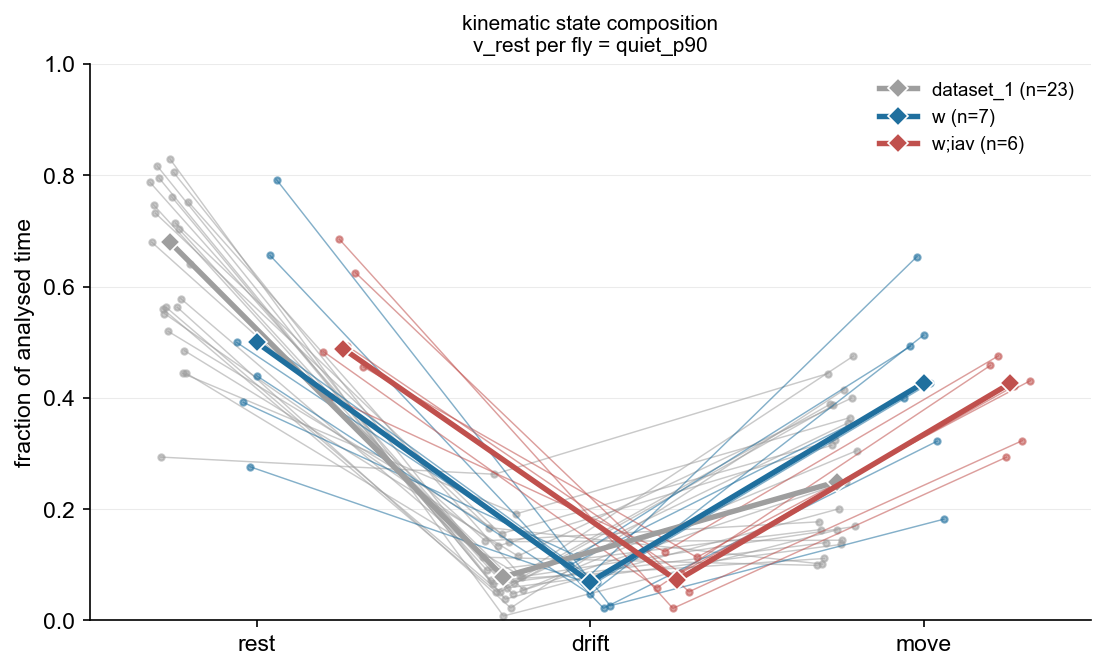

         dfc    cohort                              genotype  v_rest  quiet_floor  rest_time_fraction  drift_time_fraction  move_time_fraction  total_time
210917_F2_C1 dataset_1 +;Hot-Cell-LexA_Chr;31H05-GAL4_pJFRC7  43.000       26.139               0.294                0.263               0.444    5055.943
250924_F2_C1 dataset_1                      +;SS61350_pJFRC7  30.000       17.112               0.444                0.192               0.364    9125.429
250925_F2_C1 dataset_1                      +;SS61350_pJFRC7  30.000       17.112               0.444                0.081               0.475    9962.658
250925_F1_C1 dataset_1                      +;SS61350_pJFRC7  30.000       19.759               0.485                0.116               0.400    7800.098
250228_F1_C1 dataset_1                      +;SS61350_pJFRC7  31.000       19.759               0.520                0.156               0.324    6592.754
250227_F2_C1 dataset_1                      +;SS61350_pJFRC7  30.000  

In [92]:
# ---------------------------------------------------------------------------
# Rest / drift / move composition, several cohorts in one panel
# ---------------------------------------------------------------------------
# Same three numbers as `plot_state_fractions`, but with the cohorts overlaid so
# they can be read against each other, and in matplotlib so it saves beside the
# other rest panels. One thin line per fly, thick line for the cohort median.
#
# The three fractions sum to 1, so they carry only two degrees of freedom -- this
# panel is for looking, not for three separate tests. The compositional test in
# op_cond_Figure5_iav_mutants.ipynb (ILR coordinates + PERMANOVA) is the right
# way to test a difference in the trade-off itself.

STATE_FRACTION_COLUMNS = ('rest_time_fraction', 'drift_time_fraction',
                          'move_time_fraction')

# Fixed order, assigned by cohort and never cycled: the reference is always gray.
COHORT_PALETTE = ['#1f6f9e', '#c0504d', '#e8a33d', '#5b8c5a']


def cohort_color_map(group_names):
    """{cohort: colour} with the reference gray and groups in a fixed order."""
    colors = {REFERENCE_NAME: REFERENCE_COLOR}
    for position, name in enumerate(group_names):
        colors[name] = COHORT_PALETTE[position % len(COHORT_PALETTE)]
    return colors


def state_composition_by_fly(cohort_names, pyas_states=None):
    """Per-fly rest/drift/move fractions for each collected cohort, stacked."""
    frames = []
    for cohort_name in cohort_names:
        bouts, trials, _ = rest_frames[cohort_name]
        summary = ba.occupancy_summary_by_fly(bouts, trials,
                                              pyas_states=pyas_states)
        frames.append(summary.assign(cohort=cohort_name))
    return pd.concat(frames).rename_axis('dfc').reset_index()


def plot_state_composition(group_names, include_reference=True, save=False,
                           pyas_states=None, label_flies=False):
    """Rest / drift / move per fly, cohorts overlaid.

    group_names    : e.g. ['w', 'w;iav'] -- must already be in rest_frames.
    pyas_states    : restrict to ('hi',) or ('lo',); default pools both (the
                     fractions are per-sample, so pooling is well defined).
    label_flies    : write each fly's dfc beside its move point.
    """
    group_names = [group_names] if isinstance(group_names, str) else list(group_names)
    cohort_names = ([REFERENCE_NAME] if include_reference else []) + group_names
    missing = [n for n in cohort_names if n not in rest_frames]
    if missing:
        raise KeyError(f'not collected yet: {missing} -- run collect_rest_group first')

    composition = state_composition_by_fly(cohort_names, pyas_states=pyas_states)
    colors = cohort_color_map(group_names)
    positions = np.arange(len(STATE_FRACTION_COLUMNS))

    fig = Figure(figsize=(7.5, 4.6), dpi=150)
    FigureCanvas(fig)
    ax = fig.add_subplot(111)

    spread = 0.26 if len(cohort_names) > 1 else 0.0
    for index, cohort_name in enumerate(cohort_names):
        per_cohort = composition[composition['cohort'] == cohort_name]
        color = colors[cohort_name]
        centre = (index - (len(cohort_names) - 1) / 2) * spread
        # Fan the flies out evenly inside the cohort's slot rather than at random,
        # so no two lines land on top of each other and the figure is stable.
        offsets = np.linspace(-0.06, 0.06, max(len(per_cohort), 1))
        for offset, (_, fly) in zip(offsets, per_cohort.iterrows()):
            values = [fly[c] for c in STATE_FRACTION_COLUMNS]
            ax.plot(positions + centre + offset, values, '-o', color=color,
                    lw=0.7, ms=3.0, alpha=0.55)
            if label_flies:
                ax.annotate(fly['dfc'], (positions[-1] + centre + offset, values[-1]),
                            fontsize=6, color=color, xytext=(3, 0),
                            textcoords='offset points', va='center')
        medians = per_cohort[list(STATE_FRACTION_COLUMNS)].median()
        ax.plot(positions + centre, medians.to_numpy(), '-D', color=color, lw=2.6,
                ms=7, mec='white', mew=0.8,
                label=f'{cohort_name} (n={len(per_cohort)})', zorder=3)

    ax.set_xticks(positions)
    ax.set_xticklabels([c.replace('_time_fraction', '') for c in STATE_FRACTION_COLUMNS])
    ax.set_xlim(-0.5, len(positions) - 0.5)
    ax.set_ylim(0, 1)
    ax.set_ylabel('fraction of analysed time')
    ax.grid(True, axis='y', alpha=0.25, lw=0.5)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=9, frameon=False)
    window = '' if pyas_states is None else f' — {"/".join(pyas_states)} trials only'
    ax.set_title(f'kinematic state composition{window}\n'
                 f'v_rest per fly = {V_REST_RULE["statistic"]}', fontsize=10)
    fig.tight_layout()
    if save:
        stem = '_'.join(cache_tag(n) for n in group_names)
        save_rest_figure(fig, 'state_composition', stem)
    return fig, composition


# --- w and w;iav ------------------------------------------------------------
# Collect them first (cell above): ~13 flies, so ~10 min.
#     rest_frames['w']     = collect_rest_group(sinq_g, GROUPS['w'], 'w')
#     rest_frames['w;iav'] = collect_rest_group(sinq_g, GROUPS['w;iav'], 'w;iav')

fig_composition, composition = plot_state_composition(['w', 'w;iav'], save=True)
display(fig_composition)

print(composition[['dfc', 'cohort', 'genotype', 'v_rest', 'quiet_floor',
                   'rest_time_fraction', 'drift_time_fraction',
                   'move_time_fraction', 'total_time']]
      .sort_values(['cohort', 'rest_time_fraction'])
      .to_string(index=False, float_format=lambda v: f'{v:.3f}'))

# The per-cohort plotly version, one figure each, for the record.
# for name in ('w', 'w;iav'):
#     plot_state_fractions(name)[0].show()


saved Figure5_mutant_plots/rest_noise_floor_w_vs_dataset_1.svg


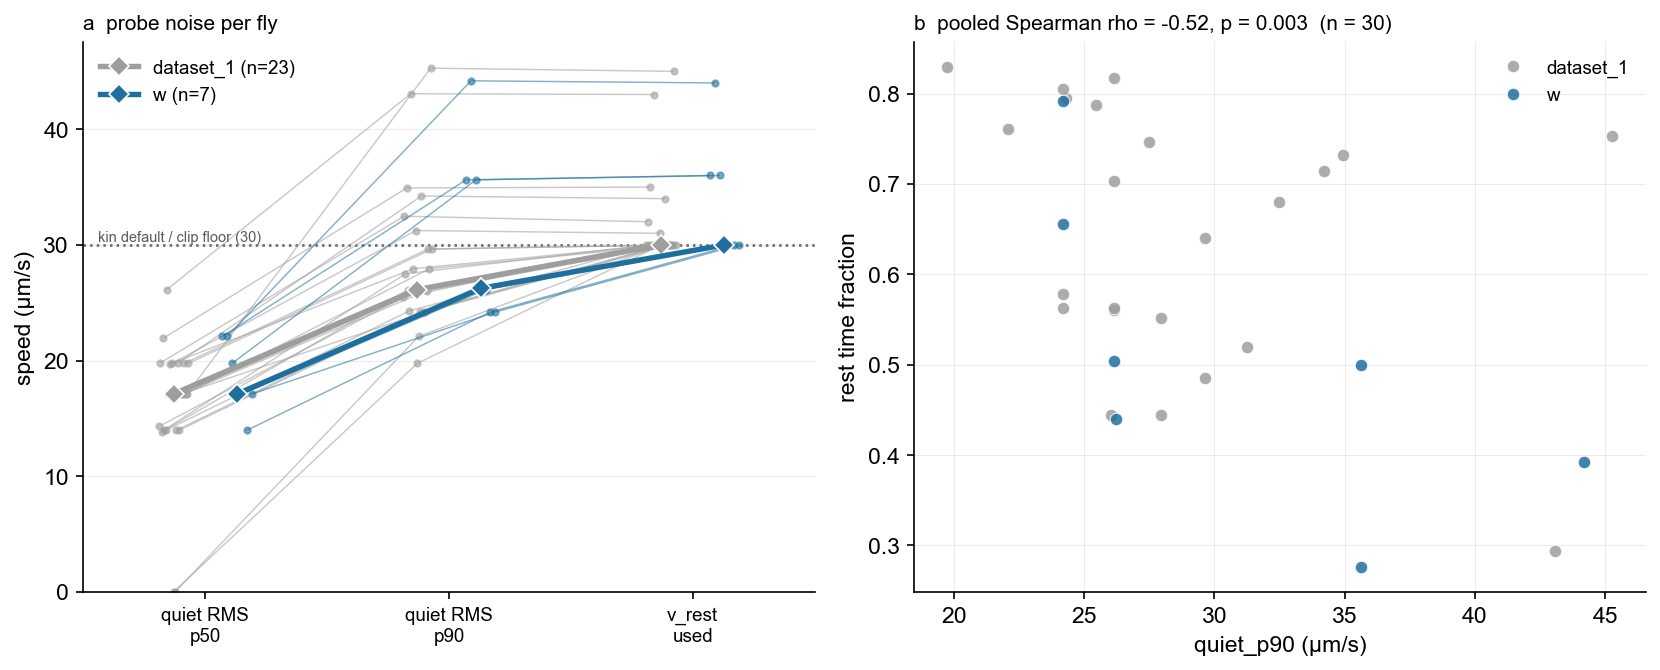

saved Figure5_mutant_plots/rest_noise_floor_w_iav_vs_dataset_1.svg


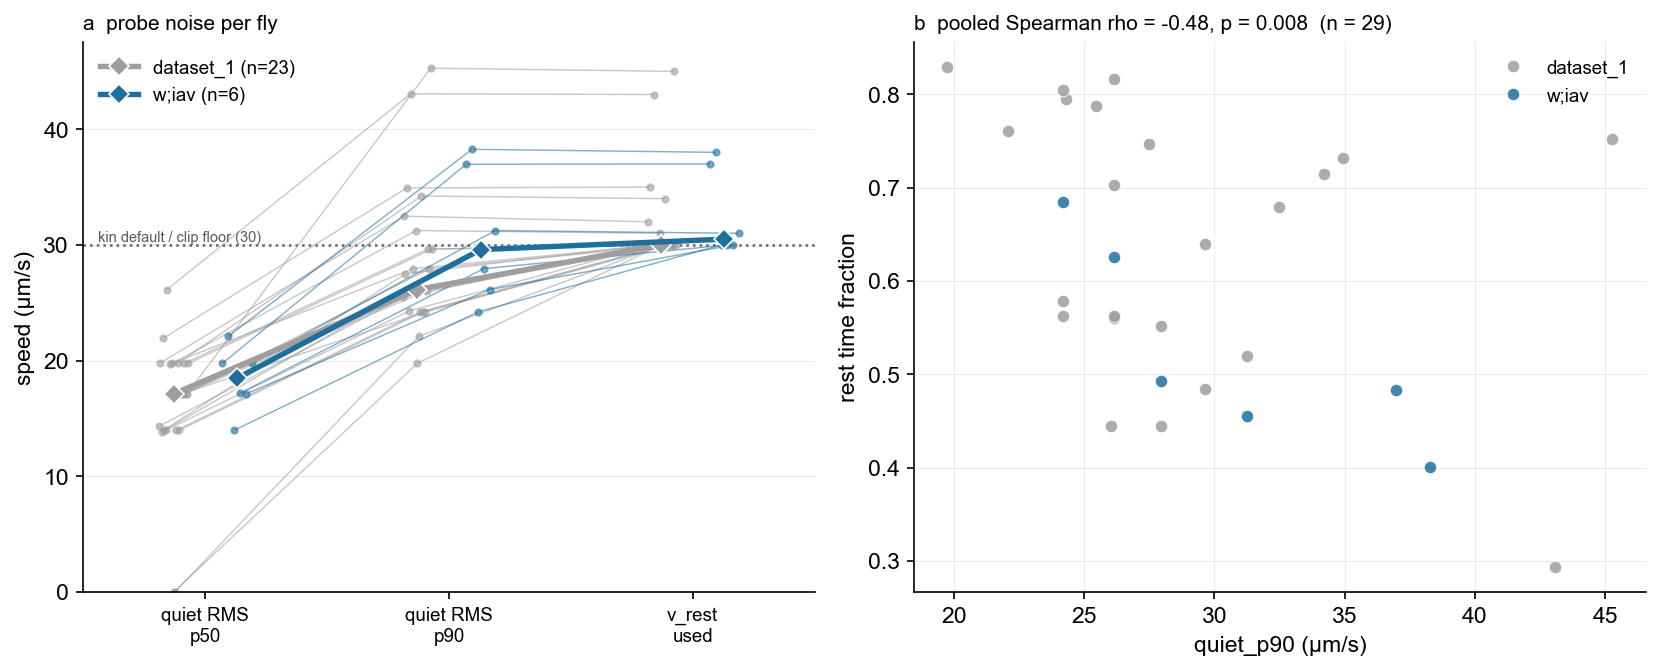

saved Figure5_mutant_plots/rest_noise_floor_PAM_vs_dataset_1.svg


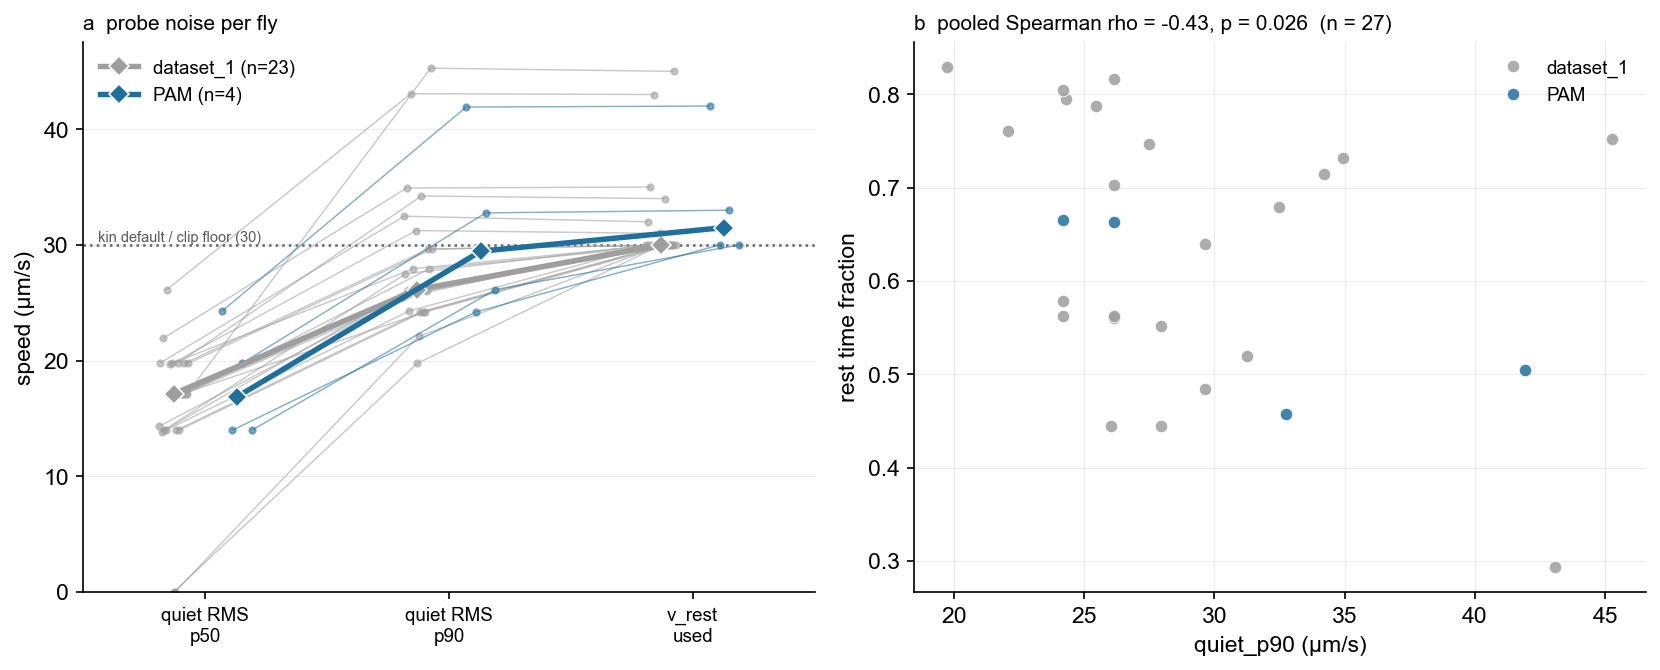

saved Figure5_mutant_plots/rest_noise_floor_PPL_vs_dataset_1.svg


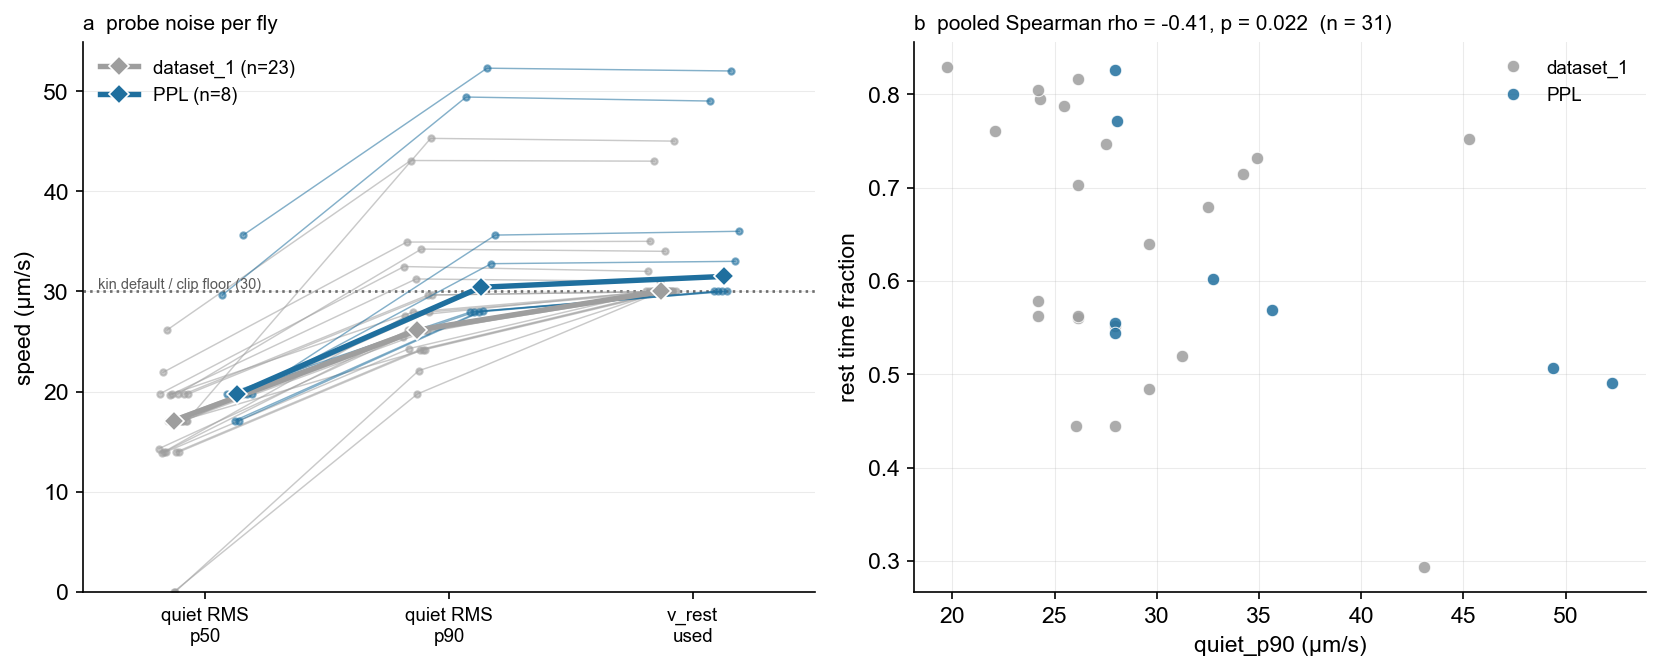

saved Figure5_mutant_plots/rest_noise_floor_+_iav_vs_dataset_1.svg


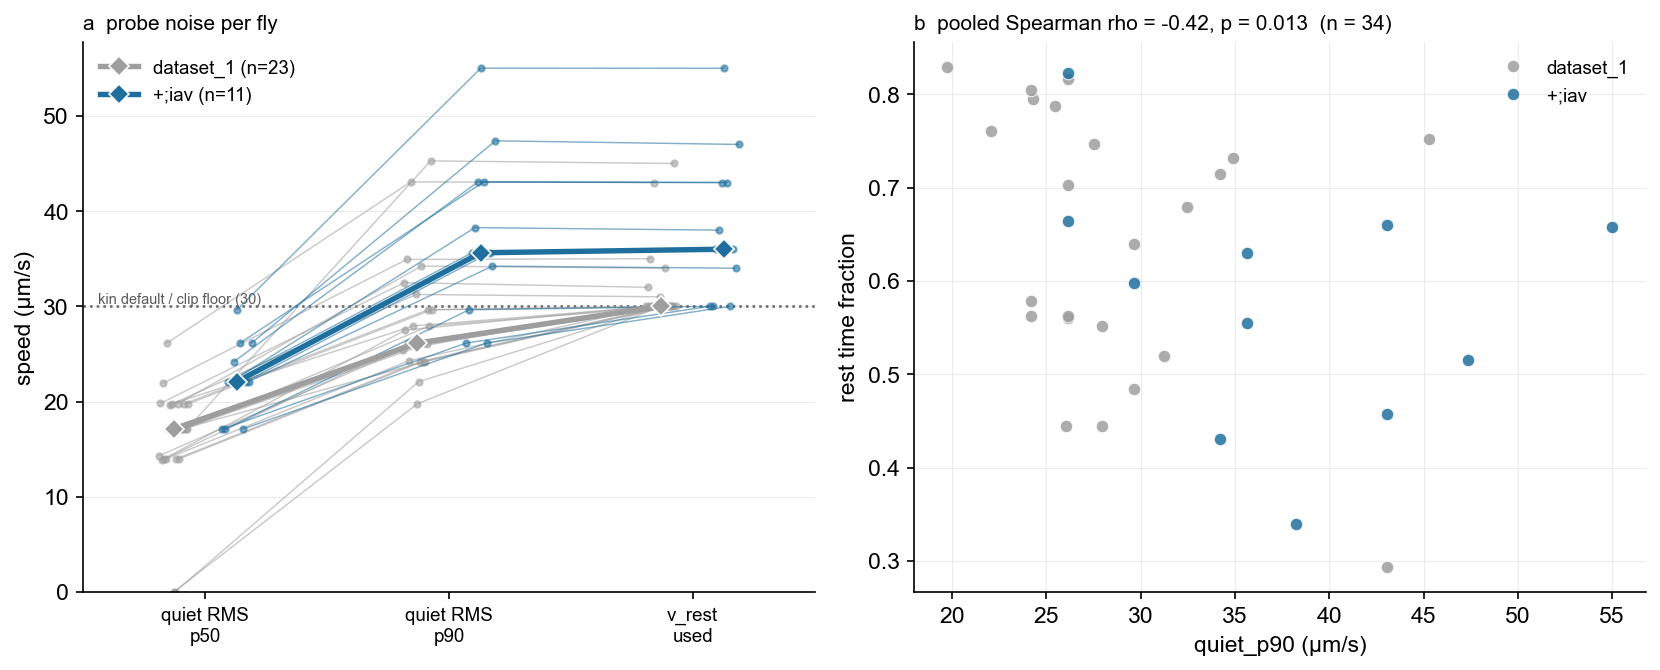

In [96]:
# ---------------------------------------------------------------------------
# The noise floor itself, cohort against cohort
# ---------------------------------------------------------------------------
# Same shape as plot_state_composition: one thin line per fly, thick diamond for
# the cohort median, reference always gray.
#
# Three measures on one axis because all three are um/s and they are nested:
# quiet_floor is the MEDIAN of the fly's non-MOVE rolling-RMS speed, quiet_p90 is
# the 90th percentile of the same distribution, and v_rest is what the p90 rule
# actually used (= quiet_p90, floored at kin.V_REST). The gap between the first
# two is the shape of that fly's noise distribution, and it varies far more than
# a scale rule would allow -- which is why v_rest keys on p90 rather than on a
# multiple of the median.
#
# Panel b asks the obvious confound directly: if a cohort's recordings are
# noisier, is its lower rest fraction just residual noise the correction did not
# reach? A cohort difference that survives at matched quiet_p90 is not explained
# by recording quality; one that lines up along the pooled trend might be.

NOISE_MEASURES = ('quiet_floor', 'quiet_p90', 'v_rest')
NOISE_MEASURE_LABELS = {'quiet_floor': 'quiet RMS\np50',
                        'quiet_p90': 'quiet RMS\np90',
                        'v_rest': 'v_rest\nused'}


def plot_noise_floor(group_names, include_reference=True, save=False,
                     label_flies=False, versus='rest_time_fraction'):
    """(a) noise measures per fly per cohort, (b) that noise vs the composition.

    versus : which composition column to plot against the noise in panel b.
             None drops the second panel.
    """
    from scipy.stats import spearmanr

    group_names = [group_names] if isinstance(group_names, str) else list(group_names)
    cohort_names = ([REFERENCE_NAME] if include_reference else []) + group_names
    missing = [n for n in cohort_names if n not in rest_frames]
    if missing:
        raise KeyError(f'not collected yet: {missing} -- run collect_rest_group first')

    composition = state_composition_by_fly(cohort_names)
    available = [m for m in NOISE_MEASURES if m in composition.columns]
    if 'quiet_p90' not in composition.columns:
        print('note: quiet_p90 is missing from this cache -- it was added to the '
              'collector after those parquets were written. Recollect to get it; '
              'v_rest still shows what was used.')
    colors = cohort_color_map(group_names)
    positions = np.arange(len(available))

    n_panels = 1 if versus is None else 2
    fig = Figure(figsize=(5.6 * n_panels, 4.6), dpi=150)
    FigureCanvas(fig)
    axes = fig.subplots(1, n_panels, squeeze=False)[0]
    floor_ax = axes[0]

    spread = 0.26 if len(cohort_names) > 1 else 0.0
    for index, cohort_name in enumerate(cohort_names):
        per_cohort = composition[composition['cohort'] == cohort_name]
        color = colors[cohort_name]
        centre = (index - (len(cohort_names) - 1) / 2) * spread
        offsets = np.linspace(-0.06, 0.06, max(len(per_cohort), 1))
        for offset, (_, fly) in zip(offsets, per_cohort.iterrows()):
            floor_ax.plot(positions + centre + offset,
                          [fly[m] for m in available], '-o', color=color,
                          lw=0.7, ms=3.0, alpha=0.55)
            if label_flies:
                floor_ax.annotate(fly['dfc'],
                                  (positions[-1] + centre + offset, fly[available[-1]]),
                                  fontsize=6, color=color, xytext=(3, 0),
                                  textcoords='offset points', va='center')
        medians = per_cohort[available].median()
        floor_ax.plot(positions + centre, medians.to_numpy(), '-D', color=color,
                      lw=2.6, ms=7, mec='white', mew=0.8, zorder=3,
                      label=f'{cohort_name} (n={len(per_cohort)})')

    floor_ax.axhline(kin.V_REST, color='0.35', ls=':', lw=1.2, zorder=1)
    floor_ax.annotate(f'kin default / clip floor ({kin.V_REST:.0f})',
                      (0.02, kin.V_REST), xycoords=('axes fraction', 'data'),
                      fontsize=7, color='0.35', va='bottom')
    floor_ax.set_xticks(positions)
    floor_ax.set_xticklabels([NOISE_MEASURE_LABELS.get(m, m) for m in available],
                             fontsize=9)
    floor_ax.set_xlim(-0.5, len(positions) - 0.5)
    floor_ax.set_ylim(bottom=0)
    floor_ax.set_ylabel('speed (µm/s)')
    floor_ax.set_title('a  probe noise per fly', fontsize=10, loc='left')
    floor_ax.grid(True, axis='y', alpha=0.25, lw=0.5)
    floor_ax.spines[['top', 'right']].set_visible(False)
    floor_ax.legend(fontsize=9, frameon=False, loc='upper left')

    if versus is not None:
        scatter_ax = axes[1]
        noise_column = 'quiet_p90' if 'quiet_p90' in composition.columns else 'quiet_floor'
        for cohort_name in cohort_names:
            per_cohort = composition[composition['cohort'] == cohort_name]
            scatter_ax.plot(per_cohort[noise_column], per_cohort[versus], 'o',
                            color=colors[cohort_name], ms=6, alpha=0.85,
                            mec='white', mew=0.5, label=cohort_name)
            if label_flies:
                for _, fly in per_cohort.iterrows():
                    scatter_ax.annotate(fly['dfc'], (fly[noise_column], fly[versus]),
                                        fontsize=6, color=colors[cohort_name],
                                        xytext=(4, 0), textcoords='offset points',
                                        va='center')
        usable = composition[[noise_column, versus]].dropna()
        if len(usable) > 2:
            rho, p_value = spearmanr(usable[noise_column], usable[versus])
            scatter_ax.set_title(f'b  pooled Spearman rho = {rho:+.2f}, p = {p_value:.3f}'
                                 f'  (n = {len(usable)})', fontsize=10, loc='left')
        else:
            scatter_ax.set_title('b', fontsize=10, loc='left')
        scatter_ax.set_xlabel(f'{noise_column} (µm/s)')
        scatter_ax.set_ylabel(versus.replace('_', ' '))
        scatter_ax.grid(True, alpha=0.25, lw=0.5)
        scatter_ax.spines[['top', 'right']].set_visible(False)
        scatter_ax.legend(fontsize=9, frameon=False)

    fig.tight_layout()
    if save:
        stem = '_'.join(cache_tag(n) for n in group_names)
        save_rest_figure(fig, 'noise_floor', stem)
    return fig, composition

group_names = ['w','w;iav','PAM','PPL','+;iav']
for group_name in group_names:
    fig_noise, noise_table = plot_noise_floor([group_name], save=True, label_flies=False)
    display(fig_noise)

    noise_columns = ['dfc', 'cohort', 'genotype', 'quiet_floor', 'quiet_p90', 'v_rest',
                    'rest_time_fraction', 'drift_time_fraction', 'move_time_fraction']
    report = noise_table[[c for c in noise_columns if c in noise_table.columns]].copy()
    if 'quiet_p90' in report.columns:
        # How heavy-tailed the quiet distribution is. A scale rule on the median
        # would have assumed this ratio is the same in every fly; it is not.
        report['p90_over_p50'] = report['quiet_p90'] / report['quiet_floor'].replace(0, np.nan)
    # print(report.sort_values(['cohort', 'quiet_floor'])
    #     .to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    # Flies whose quiet median is exactly zero: more than half their non-MOVE samples
    # have no measurable speed at all, which is a held or quantised position trace
    # rather than a quiet fly. Worth looking at before trusting their rest numbers.
    flat = report[report['quiet_floor'] <= 0]
    if len(flat):
        print('\nquiet RMS median is 0 -- check the probe trace for held/quantised '
            'samples:')
        print(flat[['dfc', 'cohort', 'quiet_floor', 'v_rest', 'rest_time_fraction']]
            .to_string(index=False, float_format=lambda v: f'{v:.3f}'))


In [97]:
w_iav_df

,Table,parquet,genotype,notes,duration,rms_velocity,outcome_fractions_no_as_no_mv,outcome_fractions_as_off,outcome_fractions_rest,outcome_fractions_no_as_mv,...,most_common_fiberLED,lo_target_off_state,hi_target_off_state,probe_positive_effort,successes,hard_successes,holding_cost,rest_time_fraction,drift_time_fraction,move_time_fraction
241205_F2_C1,None,LEDFlashTriggerPiezoControl_241205_F2_C1_Table...,iav_Kir2_1,"{'text': 'IAV Kir2.1 in [w] background', 'tags...",4592.04334,103703.773799,0.083984,0.630859,0.152344,0.103516,...,epi_only,0.371842,0.024624,3.129737e+06,64.0,8.0,5.745730e+06,0.473787,0.082867,0.443346
241205_F3_C1,None,LEDFlashTriggerPiezoControl_241205_F3_C1_Table...,w;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [w] background', 'tags...",4601.99376,199521.588854,0.003891,0.762646,0.155642,0.042802,...,epi_only,0.264464,0.049193,6.841562e+06,20.0,0.0,7.592188e+06,0.304387,0.184354,0.511259
241219_F1_C1,None,LEDFlashTriggerPiezoControl_241219_F1_C1_Table...,w;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [w] background', 'tags...",8427.33492,246895.473183,0.000000,0.759193,0.151839,0.000000,...,epi_only,0.145026,0.023368,6.295168e+06,0.0,0.0,8.077882e+06,0.705697,0.020188,0.274115
241219_F2_C1,None,LEDFlashTriggerPiezoControl_241219_F2_C1_Table...,w;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [w] background', 'tags...",5633.13292,148529.434039,0.000000,0.703642,0.172185,0.024834,...,epi_only,0.212010,0.043292,4.128245e+06,14.0,0.0,6.042135e+06,0.521343,0.093810,0.384847
241220_F1_C1,None,LEDFlashTriggerPiezoControl_241220_F1_C1_Table...,w;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [w] background', 'tags...",6633.59082,248074.713153,0.000000,0.798077,0.153846,0.015110,...,epi_only,0.221039,0.027496,6.949634e+06,11.0,0.0,8.077262e+06,0.634160,0.051451,0.314389
241220_F2_C1,None,LEDFlashTriggerPiezoControl_241220_F2_C1_Table...,w;iav-GAL4_UAS-Kir21,"{'text': 'IAV Kir2.1 in [w] background', 'tags...",7837.07546,291335.825219,0.007212,0.713942,0.153846,0.037260,...,epi_only,0.213848,0.023861,8.781938e+06,28.0,0.0,1.333849e+07,0.464890,0.127497,0.407613
